# 南米ADM2パネルデータ前処理
南米12か国 (2011–2020 年) を対象に、因果フォレスト分析向けの ADM2 パネルデータセットを整備します。

**ステップ**
1. GLocal ADM2 年次データとサポート情報の読み込み、南米・対象年のフィルタリング
2. 夜間光・鉱山処置・共変量の整形とラグ生成
3. 年次気候・土地被覆 (annualized) と WGI 制度指標の結合
4. 欠損監査と全欠損列の削除、整形後データの書き出し

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import geopandas as gpd
import requests
from zipfile import ZipFile
from io import BytesIO

# 表示設定を整えて出力を見やすくする
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# 日本語フォント設定
jp_fonts = ['Hiragino Sans','Yu Gothic','YuGothic','IPAexGothic','Noto Sans CJK JP','MS Gothic','Meiryo']
available_fonts = {f.name: f.fname for f in fm.fontManager.ttflist}
for font in jp_fonts:
    if font in available_fonts:
        plt.rcParams['font.family'] = font
        break
else:
    print('※日本語フォントが見つからないため既定フォントを使用します')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from pathlib import Path

# ルート探索：ノートブック実行場所に依存せずデータディレクトリを発見
candidate_roots = []
if '__file__' in globals():
    candidate_roots.append(Path(__file__).resolve().parent)
# カレントとその親を候補として追加
candidate_roots.extend([
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
])

# 既知の表記ゆれ（データ/データ）を考慮しつつ探索
DATA_DIR = None
for base in candidate_roots:
    for data_name in ['データ', 'データ']:
        candidate = base / data_name
        target = candidate / 'GLocal' / 'ADM2' / 'supporting_data_level_2.parquet'
        if target.exists():
            DATA_DIR = candidate.resolve()
            break
    if DATA_DIR is not None:
        break

if DATA_DIR is None:
    raise FileNotFoundError('GLocal データフォルダが見つかりませんでした。ノートブックの実行パスを確認してください。')

# 主要ディレクトリと出力先
GLOCAL_DIR = DATA_DIR / 'GLocal'
GLOCAL_ADM2_DIR = GLOCAL_DIR / 'ADM2'
EXTERNAL_DIR = DATA_DIR / 'external'
WGI_DIR = EXTERNAL_DIR / 'WGI'
OUTPUT_DIR = DATA_DIR / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Detected DATA_DIR:', DATA_DIR)

# 対象国と期間の設定
SOUTH_AMERICA_ISO3 = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'ECU',
    'GUY', 'PER', 'PRY', 'SUR', 'URY', 'VEN',
]

ANALYSIS_YEARS = list(range(2012, 2021))
LAG_SOURCE_YEAR_MIN = min(ANALYSIS_YEARS) - 1
LAG_SOURCE_YEAR_MAX = max(ANALYSIS_YEARS)

# 汎用ユーティリティ
def add_group_lag(df: pd.DataFrame, group_key: str, order_key: str, columns, lag: int = 1, suffix: str = '_lag1') -> pd.DataFrame:
    columns = [col for col in columns if col in df.columns]
    if not columns:
        return df
    df = df.sort_values([group_key, order_key]).copy()
    grouped = df.groupby(group_key, sort=False)
    for col in columns:
        df[f"{col}{suffix}"] = grouped[col].shift(lag)
    return df


def summarize_missing(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    missing = df.isna().mean().sort_values(ascending=False)
    return missing.head(top_n).to_frame('missing_ratio')

Detected DATA_DIR: /Users/saraha/Desktop/卒業研究/データ


In [3]:
# --- ADM2年次データの読み込み ---
# GLocalのADM2年次指標とサポートテーブルを全列で読み込み、対象年でフィルタ後に結合する。

unused_columns = [
    'ntl_dvnl', 'ntl_dmsp_ext', 'dmsp_cloud_free_coverage', 'dmsp_stable_lights',
    'has_tech_minerals', 'has_energy_minerals', 'has_precious_minerals', 'has_other_minerals', 'has_min_deposit',
    'fao_value', 'fao_yield',
]

support_cols = ['GID_2', 'GID_1', 'GID_0', 'area_sq_km']

# サポート情報と年次パネルを読み込み（supportはGID/areaのみ使用）
support = pd.read_parquet(
    GLOCAL_ADM2_DIR / 'supporting_data_level_2.parquet',
    columns=support_cols,
)
yearly = pd.read_parquet(GLOCAL_ADM2_DIR / 'yearly_level_2.parquet')

# 不要列を除去（urban_time_to_* もまとめて除外）
urban_time_cols = [c for c in yearly.columns if c.startswith('urban_time_to')]
yearly = yearly.drop(columns=unused_columns + urban_time_cols, errors='ignore')

print(f"raw yearly rows: {len(yearly):,}, columns: {len(yearly.columns)}")
print(f"support rows: {len(support):,}, columns: {len(support.columns)}")

# 重複列の値比較（GID_2除く）
overlap_cols = sorted(set(yearly.columns) & set(support.columns) - {'GID_2'})
if overlap_cols:
    support_idx = support.set_index('GID_2')
    dup_rows = []
    for col in overlap_cols:
        y_series = (
            yearly.dropna(subset=[col])
            .sort_values(['GID_2', 'year'])
            .groupby('GID_2', sort=False)[col]
            .first()
        )
        s_series = support_idx[col]
        aligned = y_series.reindex(s_series.index)
        mismatch = (aligned.notna()) & (s_series.notna()) & (aligned != s_series)
        support_only = s_series.notna() & aligned.isna()
        dup_rows.append({
            'variable': col,
            'support_non_null': int(s_series.notna().sum()),
            'yearly_non_null': int(aligned.notna().sum()),
            'mismatch_count': int(mismatch.sum()),
            'support_only_non_null': int(support_only.sum()),
        })
    dup_check = pd.DataFrame(dup_rows).sort_values('variable')
    display(dup_check)
else:
    print('No overlapping columns between yearly and support (except GID_2).')

# サポート結合（GID_2で many-to-one 想定）
data_full_years = yearly.merge(
    support,
    on='GID_2',
    how='left',
    validate='many_to_one',
)

# 南米12か国でフィルタ
data_full_years = data_full_years[data_full_years['GID_0'].isin(SOUTH_AMERICA_ISO3)].copy()

# 対象年フィルタ
data_raw = data_full_years[data_full_years['year'].between(min(ANALYSIS_YEARS), max(ANALYSIS_YEARS))].copy()

print(f"filtered rows: {len(data_raw):,}, columns: {len(data_raw.columns)}")
print(f"year range in data_raw: {data_raw['year'].min()} - {data_raw['year'].max()}")
print("columns (data_raw):", list(data_raw.columns))

raw yearly rows: 1,424,822, columns: 46
support rows: 45,962, columns: 4
No overlapping columns between yearly and support (except GID_2).
filtered rows: 77,193, columns: 49
year range in data_raw: 2012 - 2020
columns (data_raw): ['GID_2', 'year', 'ruggedness', 'population_count', 'road_length_tertiary_roads', 'road_length_secondary_roads', 'road_length_primary_roads', 'road_length_local_roads', 'road_length_highways', 'population_density', 'elevation', 'viirs', 'wind_potential', 'solar_potential', 'landcover_MODIS_urban_builtup', 'landcover_MODIS_savanna', 'landcover_MODIS_wetland', 'landcover_MODIS_forest', 'landcover_MODIS_water', 'landcover_MODIS_grassland', 'landcover_MODIS_cropland', 'landcover_MODIS_shrub', 'landcover_MODIS_barren', 'time_to_cities_mins', 'time_to_large_cities_mins', 'time_to_medium_cities_mins', 'time_to_ports_mins', 'time_to_airports_mins', 'forest_loss_count', 'forest_loss_sum', 'forest_loss_mean', 'has_capital', 'has_land_border', 'dist_geomcentr_to_capital_

In [4]:
# --- 変数と意味のテーブル ---
# データに含まれる変数についてコードブックから説明を抜粋する。

codebook = pd.read_csv(GLOCAL_ADM2_DIR / 'codebook.csv')
vars_in_data = set(data_raw.columns)
codebook_subset = codebook[codebook['Variable'].isin(vars_in_data)].copy()
codebook_subset = codebook_subset[[
    'Variable', 'Description', 'Units', 'Topic', 'Dataset Name', 'Source', 'Notes'
]].sort_values('Variable').reset_index(drop=True)

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(codebook_subset)
print(f"Listed {len(codebook_subset)} variables out of {len(vars_in_data)} columns.")

,Variable,Description,Units,Topic,Dataset Name,Source,Notes
0,GID_0,Global identifier for countries.,NaN,ID,NaN,NaN,NaN
1,GID_1,Global identifier for administrative unit 1.,NaN,ID,NaN,NaN,NaN
2,GID_2,Global identifier for administrative unit 2.,NaN,ID,NaN,NaN,NaN
3,elevation,Altitude,meters,Geoecologic,USGS Digital Elevation - Global 30 Arc-Second Elevation (GTOPO30),USGS,NaN
4,forest_loss_count,Land area classified as forest.,sq. m.,Geoecologic,Landcover - MODIS,MODIS,NaN
5,forest_loss_mean,Land area classified as forest.,sq. m.,Geoecologic,Landcover - MODIS,MODIS,NaN
6,forest_loss_sum,Global tree cover loss from analysis of Landsat images,sq. m.,Economic,Tree cover loss,Global Forest Change,"Some concerns around increased sensitivity after 2015/16, so time trends should be validated"
7,landcover_MODIS_barren,Land area classified as barren.,sq. m.,Geoecologic,Landcover - MODIS,MODIS,NaN
8,landcover_MODIS_cropland,Land area classified as cropland.,sq. m.,Geoecologic,Landcover - MODIS,MODIS,NaN
9,landcover_MODIS_forest,Land area classified as forest.,sq. m.,Geoecologic,Landcover - MODIS,MODIS,NaN


Listed 37 variables out of 49 columns.


,missing_ratio
ruggedness,1.000000
lat_popcentr,1.000000
dist_popcentr_to_capital_km,1.000000
has_flare,1.000000
has_large_airports,1.000000
has_int_airports,1.000000
wind_potential,1.000000
elevation,1.000000
has_medium_airports,1.000000
has_coasts,1.000000


/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_23842/757132575.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = data_raw.groupby('year').apply(_year_missing)
/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_23842/757132575.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year_full = data_full_all.groupby('year').apply(_year_missing)


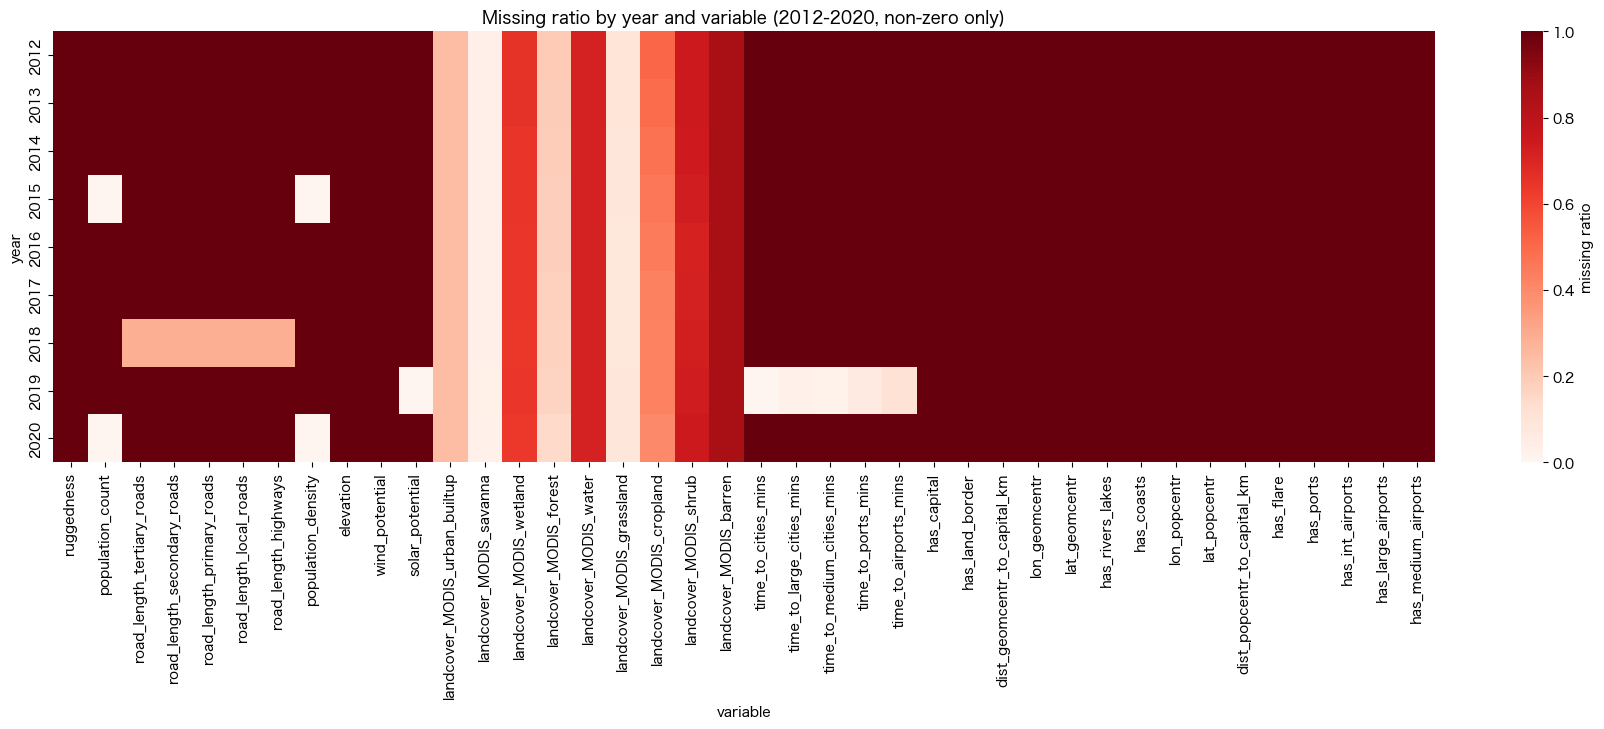

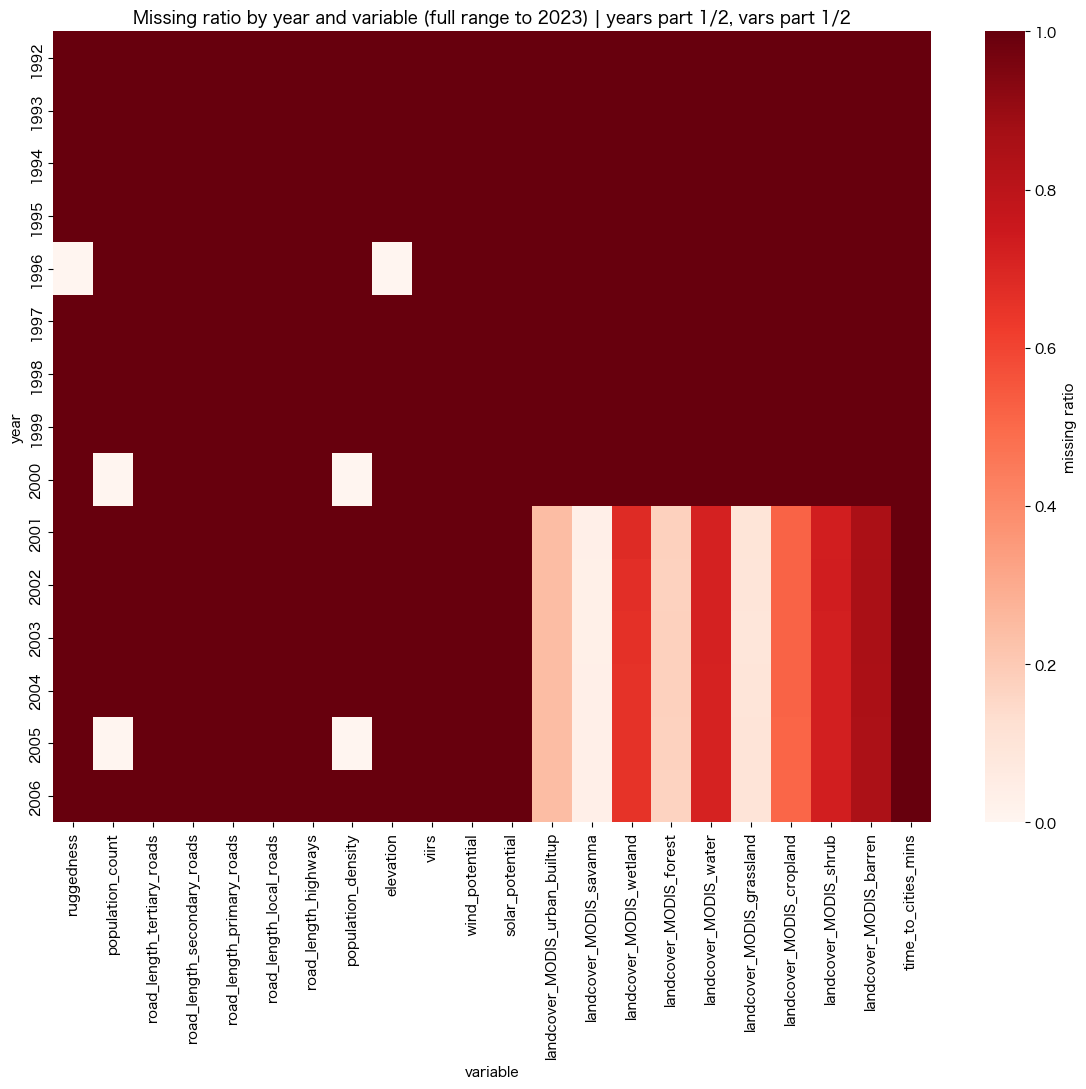

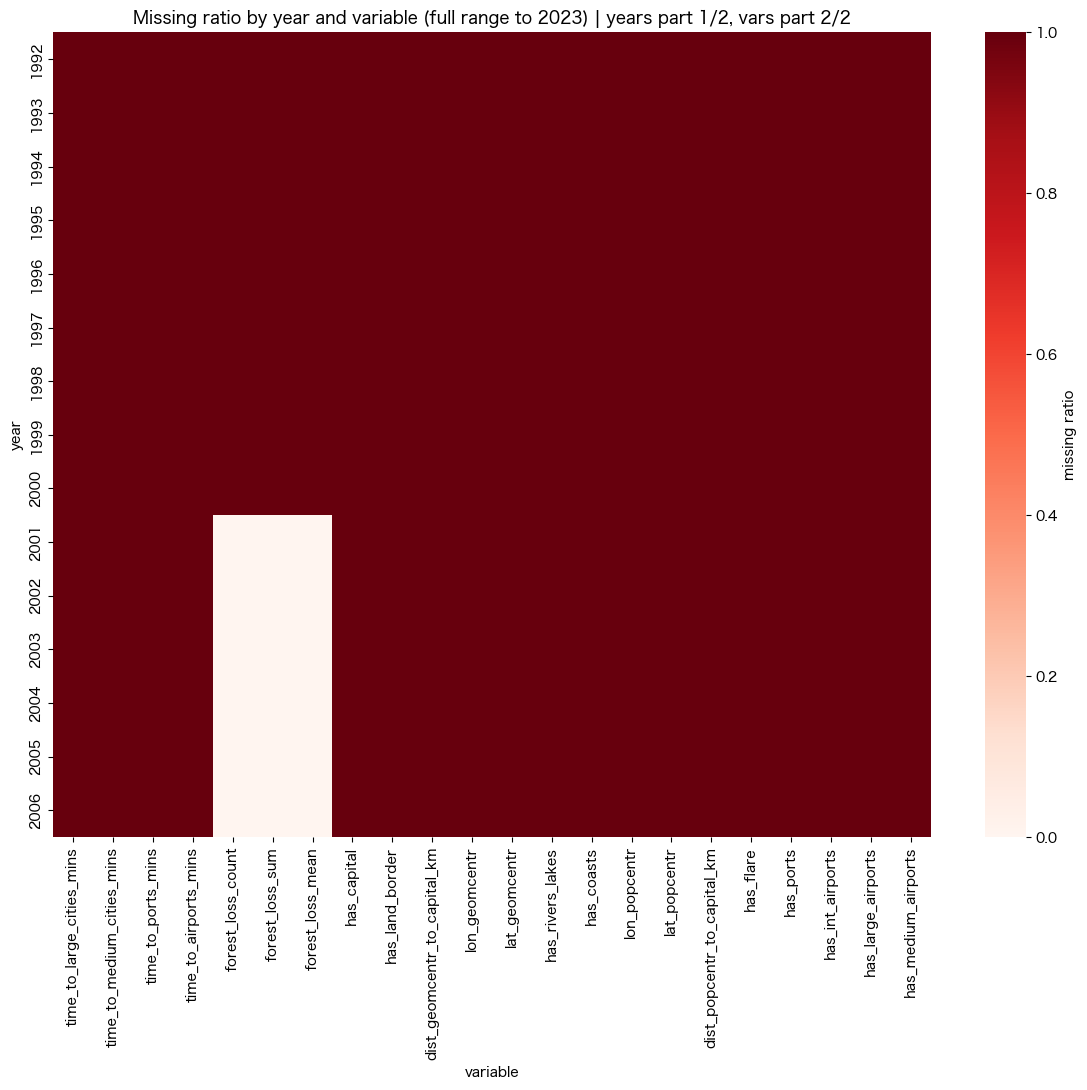

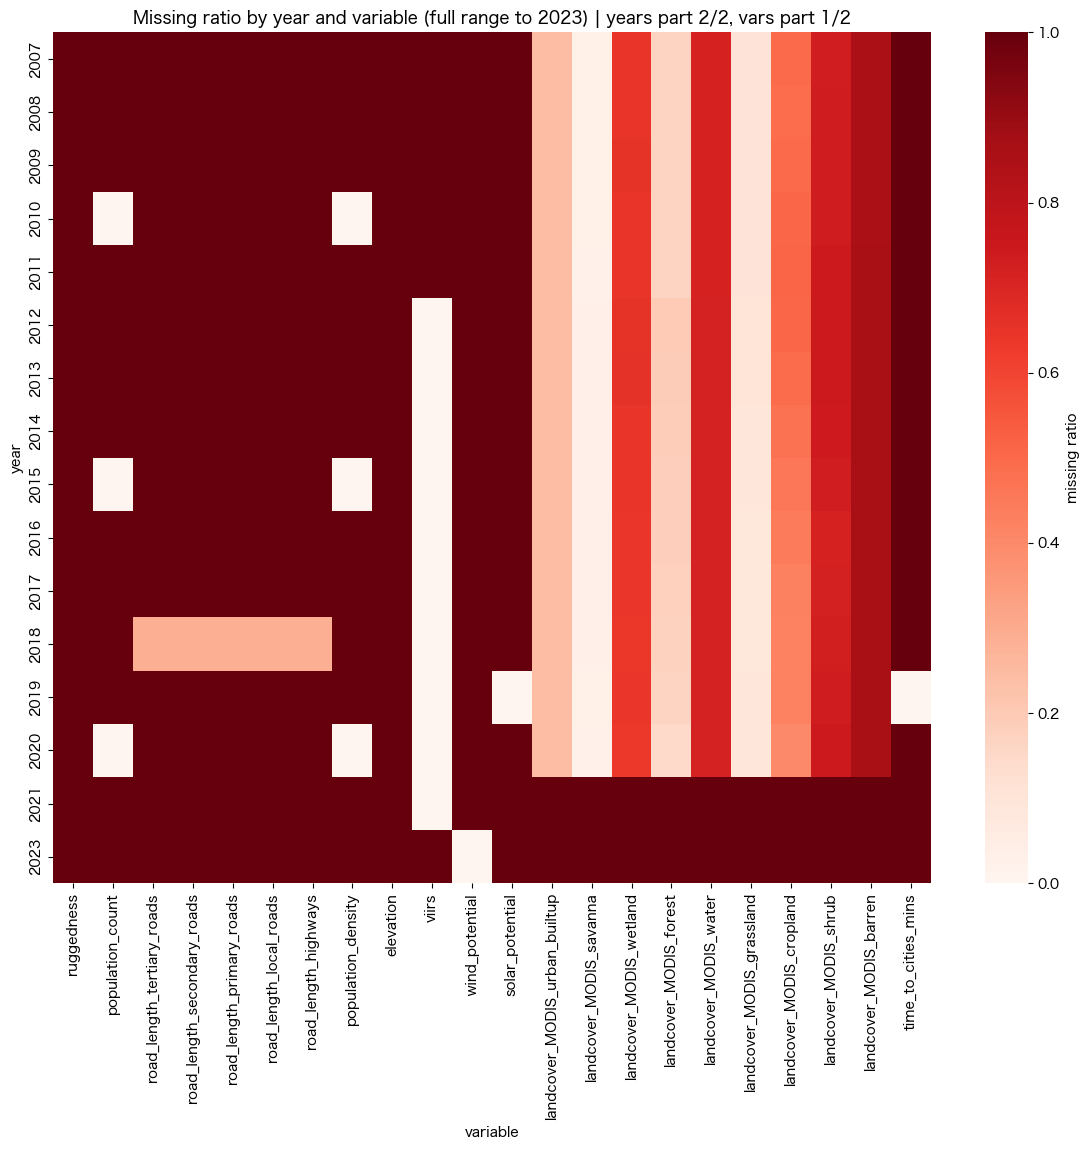

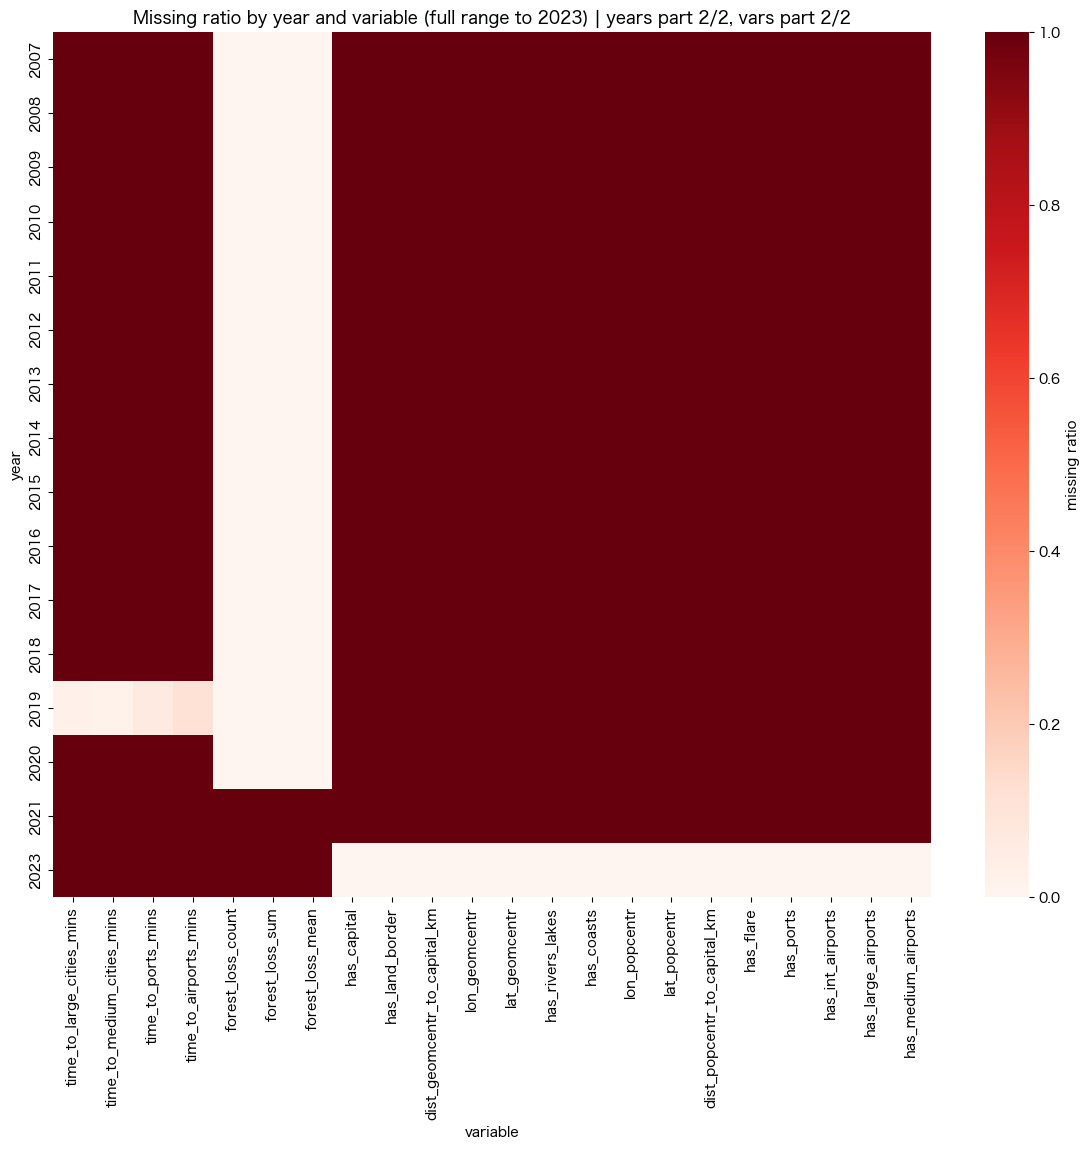

In [5]:
# --- 欠損確認 ---
# 欠損率>0の変数を抽出し、全体の欠損率テーブルとヒートマップを表示する。

import seaborn as sns

# 分析対象期間（2012-2020）の欠損率
overall_missing = data_raw.isna().mean()
missing_overall = overall_missing[overall_missing > 0].sort_values(ascending=False)
missing_table = missing_overall.to_frame('missing_ratio')

with pd.option_context('display.max_rows', None):
    display(missing_table)

# 年×変数の欠損率（分析対象期間）
def _year_missing(df):
    return df.isna().mean()

missing_by_year = data_raw.groupby('year').apply(_year_missing)
missing_by_year = missing_by_year.loc[:, (missing_by_year > 0).any(axis=0)]

if missing_by_year.empty:
    print('No missing values detected across years for analysis window.')
else:
    plt.figure(
        figsize=(
            min(18, 0.35 * missing_by_year.shape[1] + 4),
            0.6 * missing_by_year.shape[0] + 2,
        )
    )
    sns.heatmap(
        missing_by_year,
        cmap='Reds',
        cbar_kws={'label': 'missing ratio'},
        vmin=0,
    )
    plt.title('Missing ratio by year and variable (2012-2020, non-zero only)')
    plt.xlabel('variable')
    plt.ylabel('year')
    plt.tight_layout()

# 元データの全期間（最初の年〜最大年）での欠損ヒートマップを分割表示
data_full_all = data_full_years.copy()
missing_by_year_full = data_full_all.groupby('year').apply(_year_missing)
missing_by_year_full = missing_by_year_full.loc[:, (missing_by_year_full > 0).any(axis=0)]

if missing_by_year_full.empty:
    print('No missing values detected across years (full range).')
else:
    vars_with_missing = list(missing_by_year_full.columns)
    years_full = list(missing_by_year_full.index)
    if not vars_with_missing or not years_full:
        print('Missing heatmap (full range) skipped: no variables or years after filtering.')
    else:
        mid_var = max(1, len(vars_with_missing) // 2)
        mid_year = max(1, len(years_full) // 2)
        var_splits = [vars_with_missing[:mid_var], vars_with_missing[mid_var:]]
        year_splits = [years_full[:mid_year], years_full[mid_year:]]
        for yi, y_subset in enumerate(year_splits):
            for vi, v_subset in enumerate(var_splits):
                if not y_subset or not v_subset:
                    continue
                plt.figure(
                    figsize=(
                        min(14, 0.35 * len(v_subset) + 4),
                        0.6 * len(y_subset) + 2,
                    )
                )
                sns.heatmap(
                    missing_by_year_full.loc[y_subset, v_subset],
                    cmap='Reds',
                    cbar_kws={'label': 'missing ratio'},
                    vmin=0,
                )
                plt.title(
                    f"Missing ratio by year and variable (full range to {max(years_full)}) | years part {yi+1}/2, vars part {vi+1}/2"
                )
                plt.xlabel('variable')
                plt.ylabel('year')
                plt.tight_layout()


In [6]:
# --- 欠損補完（人口CAGR・静的ffill/bfill・土地被覆シェア） ---
# 欠損補完は研究対象期間（ANALYSIS_YEARS）に対して実施。

# 1) 人口: 2010/2015/2020 のスナップショットから CAGR 補間して上書き（2012-2014, 2016-2019）
ANCHOR_YEARS = (2010, 2015, 2020)
pop_cols = ['population_count', 'population_density']

data_full_imputed = data_full_years.copy()
pop_fill_rows = []
for col in pop_cols:
    anchors = data_full_imputed[data_full_imputed['year'].isin(ANCHOR_YEARS)][['GID_2', 'year', col]]
    if anchors.empty:
        pop_fill_rows.append({'variable': col, 'filled_rows': 0})
        continue
    pivot = anchors.pivot(index='GID_2', columns='year', values=col)
    a10, a15, a20 = pivot.get(2010), pivot.get(2015), pivot.get(2020)

    # CAGR をベクトルで計算（正のベースと非欠損が条件）
    cagr_10_15 = (a15 / a10) ** (1/5) - 1
    cagr_10_15 = cagr_10_15.where((a10 > 0) & a15.notna())
    cagr_15_20 = (a20 / a15) ** (1/5) - 1
    cagr_15_20 = cagr_15_20.where((a15 > 0) & a20.notna())

    fill_parts = []
    for year in [2012, 2013, 2014]:
        vals = a10 * (1 + cagr_10_15) ** (year - 2010)
        vals = vals.where(cagr_10_15.notna())
        df_year = pd.DataFrame({'GID_2': pivot.index, 'year': year, col: vals})
        fill_parts.append(df_year.dropna(subset=[col]))
    for year in [2016, 2017, 2018, 2019]:
        vals = a15 * (1 + cagr_15_20) ** (year - 2015)
        vals = vals.where(cagr_15_20.notna())
        df_year = pd.DataFrame({'GID_2': pivot.index, 'year': year, col: vals})
        fill_parts.append(df_year.dropna(subset=[col]))

    if fill_parts:
        update_df = pd.concat(fill_parts, ignore_index=True)
        data_full_imputed = data_full_imputed.merge(update_df, on=['GID_2', 'year'], how='left', suffixes=('', '_filled'))
        filled_rows = int(data_full_imputed[f'{col}_filled'].notna().sum())
        data_full_imputed[col] = data_full_imputed[col].combine_first(data_full_imputed[f'{col}_filled'])
        data_full_imputed = data_full_imputed.drop(columns=[f'{col}_filled'])
    else:
        filled_rows = 0
    pop_fill_rows.append({'variable': col, 'filled_rows': filled_rows})

pop_fill_summary = pd.DataFrame(pop_fill_rows)
print('Population CAGR filled rows (overwritten if NaN):')
print(pop_fill_summary.to_string(index=False))

# 2) 地理・地形・アクセス等の静的列を ffill/bfill（全期間でグループ埋め）
explicit_static = [
    'ruggedness', 'elevation', 'dist_popcentr_to_capital_km', 'dist_geomcentr_to_capital_km',
    'wind_potential', 'solar_potential', 'has_coasts', 'lon_popcentr', 'lat_popcentr',
    'lon_geomcentr', 'lat_geomcentr', 'has_flare', 'has_ports',
]
has_cols = [c for c in data_full_imputed.columns if c.startswith('has_')]
road_cols = [c for c in data_full_imputed.columns if c.startswith('road_length_')]
time_cols = [c for c in data_full_imputed.columns if 'time_to_' in c]
static_cols = []
for col in explicit_static + has_cols + road_cols + time_cols:
    if col in data_full_imputed.columns and col not in static_cols:
        static_cols.append(col)

if static_cols:
    data_full_imputed = data_full_imputed.sort_values(['GID_2', 'year'])
    data_full_imputed[static_cols] = (
        data_full_imputed.groupby('GID_2', sort=False)[static_cols]
        .transform(lambda s: s.ffill().bfill())
    )
    print('ffill/bfill applied to columns:', static_cols)
else:
    print('No static columns found for ffill/bfill.')

# 3) 研究対象期間に絞り込み
data_imputed = data_full_imputed[data_full_imputed['year'].between(min(ANALYSIS_YEARS), max(ANALYSIS_YEARS))].copy()

# 4) 土地被覆: 対象期間内の NaN を 0 埋め + シェア算出
landcover_cols = [c for c in data_imputed.columns if c.startswith('landcover_MODIS_')]
if landcover_cols:
    data_imputed[landcover_cols] = data_imputed[landcover_cols].fillna(0)
    landcover_sum = data_imputed[landcover_cols].sum(axis=1)
    denom = landcover_sum.replace({0: pd.NA})
    for col in landcover_cols:
        share_col = f"{col}_share"
        data_imputed[share_col] = 0.0
        valid = denom.notna()
        data_imputed.loc[valid, share_col] = data_imputed.loc[valid, col] / denom[valid]
    print('Landcover filled with 0 and share columns added:', landcover_cols)
else:
    print('No landcover columns found.')

# 5) elevation / population が欠損の行を除外（対象期間）
drop_subset = ['elevation', 'population_count', 'population_density']
initial_rows = len(data_imputed)
data_imputed = data_imputed.dropna(subset=drop_subset)
print(f"Dropped {initial_rows - len(data_imputed):,} rows due to NaN in {drop_subset} (analysis period)")

# 6) 対象期間の欠損率テーブル（0%超のみ）
missing_after = data_imputed.isna().mean()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
with pd.option_context('display.max_rows', None):
    display(missing_after.to_frame('missing_ratio'))
print(f"Remaining columns with missing>0: {len(missing_after)}")

# 解析用データ
analysis_df = data_imputed


Population CAGR filled rows (overwritten if NaN):
          variable  filled_rows
  population_count        60025
population_density        60025
ffill/bfill applied to columns: ['ruggedness', 'elevation', 'dist_popcentr_to_capital_km', 'dist_geomcentr_to_capital_km', 'wind_potential', 'solar_potential', 'has_coasts', 'lon_popcentr', 'lat_popcentr', 'lon_geomcentr', 'lat_geomcentr', 'has_flare', 'has_ports', 'has_capital', 'has_land_border', 'has_rivers_lakes', 'has_int_airports', 'has_large_airports', 'has_medium_airports', 'road_length_tertiary_roads', 'road_length_secondary_roads', 'road_length_primary_roads', 'road_length_local_roads', 'road_length_highways', 'time_to_cities_mins', 'time_to_large_cities_mins', 'time_to_medium_cities_mins', 'time_to_ports_mins', 'time_to_airports_mins']
Landcover filled with 0 and share columns added: ['landcover_MODIS_urban_builtup', 'landcover_MODIS_savanna', 'landcover_MODIS_wetland', 'landcover_MODIS_forest', 'landcover_MODIS_water', 'landcover_

,missing_ratio
road_length_tertiary_roads,0.285833
road_length_secondary_roads,0.285833
road_length_primary_roads,0.285833
road_length_local_roads,0.285833
road_length_highways,0.285833
time_to_airports_mins,0.115165
time_to_ports_mins,0.062320
time_to_large_cities_mins,0.026157
time_to_medium_cities_mins,0.022424
time_to_cities_mins,0.002592


Remaining columns with missing>0: 10


In [7]:
# --- 欠損サンプル確認（road_length系・time_to系） ---
road_cols = [c for c in analysis_df.columns if c.startswith('road_length_')]
time_cols = [c for c in analysis_df.columns if 'time_to_' in c]

# road_length系の欠損行サンプル
if road_cols:
    road_missing = analysis_df[analysis_df[road_cols].isna().any(axis=1)]
    subset_cols = ['GID_2', 'GID_1', 'GID_0', 'year'] + road_cols
    print(f"road_length missing rows: {len(road_missing):,}")
    display(road_missing[subset_cols].head(15))
else:
    print('No road_length columns found.')

# time_to系で欠損率>0の列ごとにサンプルを表示
if time_cols:
    missing_ratios = analysis_df[time_cols].isna().mean()
    missing_time_cols = [c for c, r in missing_ratios.items() if r > 0]
    if not missing_time_cols:
        print('No time_to columns with missing > 0.')
    else:
        for col in missing_time_cols:
            sample = analysis_df[analysis_df[col].isna()][['GID_2','GID_1','GID_0','year', col]].head(5)
            total_missing = int(analysis_df[col].isna().sum())
            print(f"\nMissing samples for {col} (showing up to 5 rows; missing rows: {len(sample)} / {total_missing}):")
            display(sample)
else:
    print('No time_to columns found.')


road_length missing rows: 22,052


,GID_2,GID_1,GID_0,year,road_length_tertiary_roads,road_length_secondary_roads,road_length_primary_roads,road_length_local_roads,road_length_highways
171647,ARG.1.108_1,ARG.1_1,ARG,2012,NaN,NaN,NaN,NaN,NaN
180224,ARG.1.108_1,ARG.1_1,ARG,2013,NaN,NaN,NaN,NaN,NaN
199956,ARG.1.108_1,ARG.1_1,ARG,2014,NaN,NaN,NaN,NaN,NaN
230823,ARG.1.108_1,ARG.1_1,ARG,2015,NaN,NaN,NaN,NaN,NaN
195146,ARG.1.108_1,ARG.1_1,ARG,2016,NaN,NaN,NaN,NaN,NaN
190200,ARG.1.108_1,ARG.1_1,ARG,2017,NaN,NaN,NaN,NaN,NaN
235190,ARG.1.108_1,ARG.1_1,ARG,2018,NaN,NaN,NaN,NaN,NaN
248909,ARG.1.108_1,ARG.1_1,ARG,2019,NaN,NaN,NaN,NaN,NaN
244173,ARG.1.108_1,ARG.1_1,ARG,2020,NaN,NaN,NaN,NaN,NaN
171783,ARG.8.9_1,ARG.8_1,ARG,2012,NaN,NaN,NaN,NaN,NaN



Missing samples for time_to_cities_mins (showing up to 5 rows; missing rows: 5 / 200):


,GID_2,GID_1,GID_0,year,time_to_cities_mins
171829,ARG.11.13_1,ARG.11_1,ARG,2012,NaN
180406,ARG.11.13_1,ARG.11_1,ARG,2013,NaN
195492,ARG.11.13_1,ARG.11_1,ARG,2014,NaN
235031,ARG.11.13_1,ARG.11_1,ARG,2015,NaN
199474,ARG.11.13_1,ARG.11_1,ARG,2016,NaN



Missing samples for time_to_large_cities_mins (showing up to 5 rows; missing rows: 5 / 2018):


...

,GID_2,GID_1,GID_0,year,time_to_medium_cities_mins
171829,ARG.11.13_1,ARG.11_1,ARG,2012,NaN
180406,ARG.11.13_1,ARG.11_1,ARG,2013,NaN
195492,ARG.11.13_1,ARG.11_1,ARG,2014,NaN
235031,ARG.11.13_1,ARG.11_1,ARG,2015,NaN
199474,ARG.11.13_1,ARG.11_1,ARG,2016,NaN



Missing samples for time_to_ports_mins (showing up to 5 rows; missing rows: 5 / 4808):


,GID_2,GID_1,GID_0,year,time_to_ports_mins
171811,ARG.10.11_1,ARG.10_1,ARG,2012,NaN
180388,ARG.10.11_1,ARG.10_1,ARG,2013,NaN
252336,ARG.10.11_1,ARG.10_1,ARG,2014,NaN
246726,ARG.10.11_1,ARG.10_1,ARG,2015,NaN
211445,ARG.10.11_1,ARG.10_1,ARG,2016,NaN



Missing samples for time_to_airports_mins (showing up to 5 rows; missing rows: 5 / 8885):


,GID_2,GID_1,GID_0,year,time_to_airports_mins
171639,ARG.1.100_1,ARG.1_1,ARG,2012,NaN
180216,ARG.1.100_1,ARG.1_1,ARG,2013,NaN
229854,ARG.1.100_1,ARG.1_1,ARG,2014,NaN
200864,ARG.1.100_1,ARG.1_1,ARG,2015,NaN
233746,ARG.1.100_1,ARG.1_1,ARG,2016,NaN


In [8]:
# --- 追加欠損補完（road_length系・time_to系） ---
road_cols = [c for c in analysis_df.columns if c.startswith('road_length_')]
time_cols = [c for c in analysis_df.columns if 'time_to_' in c]

# 作業用コピー
data_fix = analysis_df.copy()

# road_length: GID_2単位で全欠損の地域は0埋め＋構造フラグ
if road_cols:
    gid_all_missing = (
        data_fix.groupby('GID_2')[road_cols]
        .apply(lambda g: g.isna().all().all())
    )
    structural_ids = set(gid_all_missing[gid_all_missing].index)
    data_fix['road_length_structural_flag'] = 0
    if structural_ids:
        mask_struct = data_fix['GID_2'].isin(structural_ids) & data_fix[road_cols].isna().any(axis=1)
        data_fix.loc[mask_struct, road_cols] = 0
        data_fix.loc[data_fix['GID_2'].isin(structural_ids), 'road_length_structural_flag'] = 1

    # それ以外の欠損をGID_2×列の中央値で補完＋フラグ
    medians = data_fix.groupby('GID_2')[road_cols].transform('median')
    road_missing_mask = data_fix[road_cols].isna().any(axis=1)
    data_fix['road_length_imputed_flag'] = 0
    data_fix.loc[road_missing_mask, 'road_length_imputed_flag'] = 1
    data_fix[road_cols] = data_fix[road_cols].fillna(medians)
else:
    print('No road_length columns found.')

# time_to: has_ports/has_int_airportsで構造判定、残りは中央値補完
if time_cols:
    data_fix = data_fix.copy()
    for col in time_cols:
        struct_mask = data_fix[col].isna()
        if 'port' in col:
            if 'has_ports' in data_fix.columns:
                struct_mask = struct_mask & (data_fix['has_ports'] == 0)
            else:
                struct_mask = struct_mask & False
        if 'airport' in col:
            if 'has_int_airports' in data_fix.columns:
                struct_mask = struct_mask & (data_fix['has_int_airports'] == 0)
            else:
                struct_mask = struct_mask & False
        # 構造的欠損を大定数で埋める
        fill_const = 1440
        data_fix[f'{col}_structural_flag'] = 0
        if struct_mask.any():
            data_fix.loc[struct_mask, col] = fill_const
            data_fix.loc[struct_mask, f'{col}_structural_flag'] = 1
        # 残りの欠損をGID_2中央値で補完
        med = data_fix.groupby('GID_2')[col].transform('median')
        miss_mask = data_fix[col].isna()
        data_fix[f'{col}_imputed_flag'] = 0
        if miss_mask.any():
            data_fix.loc[miss_mask, f'{col}_imputed_flag'] = 1
            data_fix.loc[miss_mask, col] = med[miss_mask]
else:
    print('No time_to columns found.')

# 補完後の欠損率（0%超のみ）
missing_post = data_fix.isna().mean()
missing_post = missing_post[missing_post > 0].sort_values(ascending=False)
with pd.option_context('display.max_rows', None):
    display(missing_post.to_frame('missing_ratio'))
print(f"Columns still missing>0: {len(missing_post)}")

# time_to_airports_mins / time_to_ports_mins が残る行をドロップ
cols_drop_na = [c for c in ['time_to_airports_mins', 'time_to_ports_mins'] if c in data_fix.columns]
if cols_drop_na:
    drop_mask = data_fix[cols_drop_na].isna().any(axis=1)
    drop_count = int(drop_mask.sum())
    data_fix = data_fix.loc[~drop_mask].copy()
    print(f"Dropped {drop_count} rows due to NaN in {cols_drop_na}.")
else:
    print('No time_to_airports_mins/time_to_ports_mins columns found; no row drop applied.')

# データを更新
analysis_df = data_fix
print(f"analysis_df shape after road/time_to fixes: {analysis_df.shape}")


,missing_ratio
time_to_airports_mins,0.008866
time_to_ports_mins,0.000350


Columns still missing>0: 2
Dropped 702 rows due to NaN in ['time_to_airports_mins', 'time_to_ports_mins'].
analysis_df shape after road/time_to fixes: (76448, 70)


In [9]:
# --- WGI (制度指標) の統合 ---
# WGIは国レベルのみ。年次標準化してADM2に GID_0 経由で複製する。

wgi_raw = pd.read_csv(WGI_DIR / 'wgi_south_america.csv')
wgi_raw = wgi_raw[wgi_raw['year'].between(min(ANALYSIS_YEARS), max(ANALYSIS_YEARS))].copy()

wgi_pivot = wgi_raw.pivot_table(
    index=['countryiso3code', 'year'],
    columns='indicator_code',
    values='value',
    aggfunc='mean',
).reset_index()

indicator_cols = [c for c in wgi_pivot.columns if c not in ['countryiso3code', 'year']]
wgi_std = wgi_pivot.copy()
for col in indicator_cols:
    wgi_std[col] = wgi_std.groupby('year')[col].transform(lambda s: (s - s.mean()) / s.std())

wgi_std['institution_index'] = wgi_std[indicator_cols].mean(axis=1)
wgi_std = wgi_std.rename(columns={'countryiso3code': 'GID_0'})

before_rows = len(analysis_df)
analysis_df = analysis_df.merge(
    wgi_std,
    on=['GID_0', 'year'],
    how='left',
    validate='many_to_one',
)
print(f"Merged WGI: {len(analysis_df)} rows (before {before_rows}). New columns: {indicator_cols + ['institution_index']}")


Merged WGI: 76448 rows (before 76448). New columns: ['CC.EST', 'GE.EST', 'PV.EST', 'RL.EST', 'RQ.EST', 'VA.EST', 'institution_index']


In [10]:
# --- Global Mining Polygons を用いた ADM2 掘削指標の作成 ---
# GADM3.6 ADM2 境界で鉱山ポリゴンをクリップし、mine_presence/mine_site_count/mine_area_km2 を付与。

# 入力パス
mine_path = EXTERNAL_DIR / 'Global_mining_polygons' / 'global_mining_polygons_v1.gpkg'
if not mine_path.exists():
    raise FileNotFoundError(f"Mining polygons not found at {mine_path}")

# ADM2境界ファイル探索（GADM3.6 shapefile, level 2）
adm2_paths = []
for iso in SOUTH_AMERICA_ISO3:
    zip_path = GLOCAL_ADM2_DIR / f"gadm36_{iso}_shp.zip"
    shp_inside = f"gadm36_{iso}_2.shp"
    if zip_path.exists():
        adm2_paths.append(f"zip://{zip_path}!{shp_inside}")
        continue
    shp_path = GLOCAL_ADM2_DIR / shp_inside
    if shp_path.exists():
        adm2_paths.append(shp_path)

if not adm2_paths:
    raise FileNotFoundError('GADM3.6 ADM2 shapefiles not found (expected gadm36_<ISO>_shp.zip).')

print('Using ADM2 boundary files (GADM3.6):', len(adm2_paths))

# 1) ADM2を読み込み結合
adm2_list = []
for path in adm2_paths:
    gdf = gpd.read_file(path)
    keep_cols = [c for c in ['GID_2', 'GID_1', 'GID_0', 'geometry'] if c in gdf.columns]
    if len(keep_cols) < 4:
        raise ValueError(f"Missing GID columns in {path}")
    gdf = gdf[keep_cols]
    adm2_list.append(gdf)

adm2_gdf = gpd.GeoDataFrame(pd.concat(adm2_list, ignore_index=True), crs=adm2_list[0].crs)
print('ADM2 features loaded:', len(adm2_gdf))

# 2) 鉱山ポリゴン前処理
mines = gpd.read_file(mine_path)
mines = mines.explode(index_parts=False).reset_index(drop=True)
mines['geometry'] = mines['geometry'].buffer(0)
if mines.crs is None:
    raise ValueError('Mining polygons have no CRS. Please set CRS in the source file.')

# 3) 投影と面積計算
if adm2_gdf.crs is None:
    raise ValueError('ADM2 boundary file has no CRS. Please set CRS.')
TARGET_CRS = 'EPSG:6933'
adm2_proj = adm2_gdf.to_crs(TARGET_CRS)
mines_proj = mines.to_crs(TARGET_CRS)
mines_proj['mine_area_km2'] = mines_proj.geometry.area / 1e6

# 4) ADM2との交差（面積ベース）
MIN_AREA_KM2 = 0.01
intersect = gpd.overlay(
    mines_proj[['geometry', 'mine_area_km2']],
    adm2_proj[['GID_2', 'geometry']],
    how='intersection'
)
intersect['mine_area_km2'] = intersect.geometry.area / 1e6
if MIN_AREA_KM2 is not None:
    intersect = intersect[intersect['mine_area_km2'] >= MIN_AREA_KM2]

# 5) ADM2単位の集計
agg = (
    intersect.groupby('GID_2')
    .agg(mine_site_count=('mine_area_km2', 'count'),
         mine_area_km2=('mine_area_km2', 'sum'))
    .reset_index()
)
agg['mine_presence'] = (agg['mine_site_count'] > 0).astype(int)

print('Mine aggregation head:')
print(agg.head())
print('Mine area summary (km^2):')
print(agg['mine_area_km2'].describe())

# 6) 分析データへの結合（静的なので year は不要）
before_rows = len(analysis_df)
analysis_df = analysis_df.merge(agg, on='GID_2', how='left')
analysis_df[['mine_site_count', 'mine_area_km2', 'mine_presence']] = analysis_df[
    ['mine_site_count', 'mine_area_km2', 'mine_presence']
].fillna(0)
print(f"Merged mining aggregates: {len(analysis_df)} rows (before {before_rows}).")

# 国別サマリ（省略なし）
if 'GID_0' in analysis_df.columns:
    country_summary = (
        analysis_df.groupby('GID_0')[['mine_site_count', 'mine_area_km2']]
        .sum()
        .sort_values('mine_site_count', ascending=False)
    )
    print('Country-level mining summary:')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        print(country_summary.to_string())


Using ADM2 boundary files (GADM3.6): 12
ADM2 features loaded: 8577
Mine aggregation head:
         GID_2  mine_site_count  mine_area_km2  mine_presence
0  ARG.10.12_1                2     380.844429              1
1   ARG.10.2_1                2       6.922038              1
2   ARG.10.4_1                3      10.606028              1
3   ARG.10.7_1                9       6.112464              1
4  ARG.16.11_1                5       5.216928              1
Mine area summary (km^2):
count     287.000000
mean       31.295221
std       127.452834
min         0.016202
25%         1.380937
50%         4.251956
75%        19.716262
max      1670.033390
Name: mine_area_km2, dtype: float64
Merged mining aggregates: 76448 rows (before 76448).
Country-level mining summary:
       mine_site_count  mine_area_km2
GID_0                                
BRA             4653.0   13441.765345
PER             2547.0    7284.563419
GUY             1224.0    2133.069805
COL              639.0    4569.1931

In [11]:
# --- 隣接を含めた鉱山処置フラグの作成 ---
# 隣接ADM2に鉱山がある場合も処置=1とする拡張フラグを作成

# ADM2境界をGADM3.6から読み込み（鉱山セルと同じソース）
adm2_paths = []
for iso in SOUTH_AMERICA_ISO3:
    zip_path = GLOCAL_ADM2_DIR / f"gadm36_{iso}_shp.zip"
    shp_inside = f"gadm36_{iso}_2.shp"
    if zip_path.exists():
        adm2_paths.append(f"zip://{zip_path}!{shp_inside}")
        continue
    shp_path = GLOCAL_ADM2_DIR / shp_inside
    if shp_path.exists():
        adm2_paths.append(shp_path)

if not adm2_paths:
    raise FileNotFoundError('GADM3.6 ADM2 shapefiles not found for neighbor computation.')

adm2_list = []
for path in adm2_paths:
    gdf = gpd.read_file(path)
    keep_cols = [c for c in ['GID_2','geometry'] if c in gdf.columns]
    gdf = gdf[keep_cols]
    adm2_list.append(gdf)

adm2_gdf = gpd.GeoDataFrame(pd.concat(adm2_list, ignore_index=True), crs=adm2_list[0].crs)

# 隣接判定（touches）。自己結合を除外。
neighbors = gpd.sjoin(
    adm2_gdf[['GID_2','geometry']],
    adm2_gdf[['GID_2','geometry']],
    how='left',
    predicate='touches'
)
neighbors = neighbors[neighbors['GID_2_left'] != neighbors['GID_2_right']]
neighbor_map = neighbors.groupby('GID_2_left')['GID_2_right'].apply(lambda s: list(set(s.dropna())))

presence_series = analysis_df.groupby('GID_2')['mine_presence'].max()

def has_neighbor_mine(gid):
    neigh = neighbor_map.get(gid, [])
    if not neigh:
        return 0
    return int(presence_series.reindex(neigh).fillna(0).gt(0).any())

analysis_df['mine_presence_neighbor'] = analysis_df['GID_2'].map(has_neighbor_mine)
analysis_df['mine_presence_expanded'] = (
    (analysis_df['mine_presence'] == 1) |
    (analysis_df['mine_presence_neighbor'] == 1)
).astype(int)

print('Expanded mine presence flags created.')
print(analysis_df[['mine_presence','mine_presence_neighbor','mine_presence_expanded']].sum())


Expanded mine presence flags created.
mine_presence             2466.0
mine_presence_neighbor    9342.0
mine_presence_expanded    9711.0
dtype: float64


In [12]:
# --- 国別の鉱山処置割合 ---
country_presence = (
    analysis_df.groupby('GID_0')[['mine_presence', 'mine_presence_expanded']]
    .mean()
    .sort_values('mine_presence_expanded', ascending=False)
)
print('Country-level mine presence (share of ADM2 with mines):')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    print(country_presence.to_string())


Country-level mine presence (share of ADM2 with mines):
       mine_presence  mine_presence_expanded
GID_0                                       
PER         0.276923                0.707692
CHL         0.363636                0.696970
SUR         0.209677                0.564516
BOL         0.095745                0.425532
GUY         0.086207                0.336207
ECU         0.031390                0.165919
COL         0.024482                0.111111
ARG         0.032120                0.109208
VEN         0.026627                0.103550
BRA         0.021268                0.100341
URY         0.010526                0.057895
PRY         0.000000                0.000000


In [13]:
# --- 数値列を float32 にダウンキャスト ---
float_cols = analysis_df.select_dtypes(include=['float64', 'float32']).columns
before = analysis_df[float_cols].memory_usage(deep=True).sum()
analysis_df[float_cols] = analysis_df[float_cols].astype('float32')
after = analysis_df[float_cols].memory_usage(deep=True).sum()
print(f"Float columns cast to float32. Memory: {before/1e6:.2f} MB -> {after/1e6:.2f} MB ({len(float_cols)} cols)")


Float columns cast to float32. Memory: 39.14 MB -> 19.57 MB (64 cols)


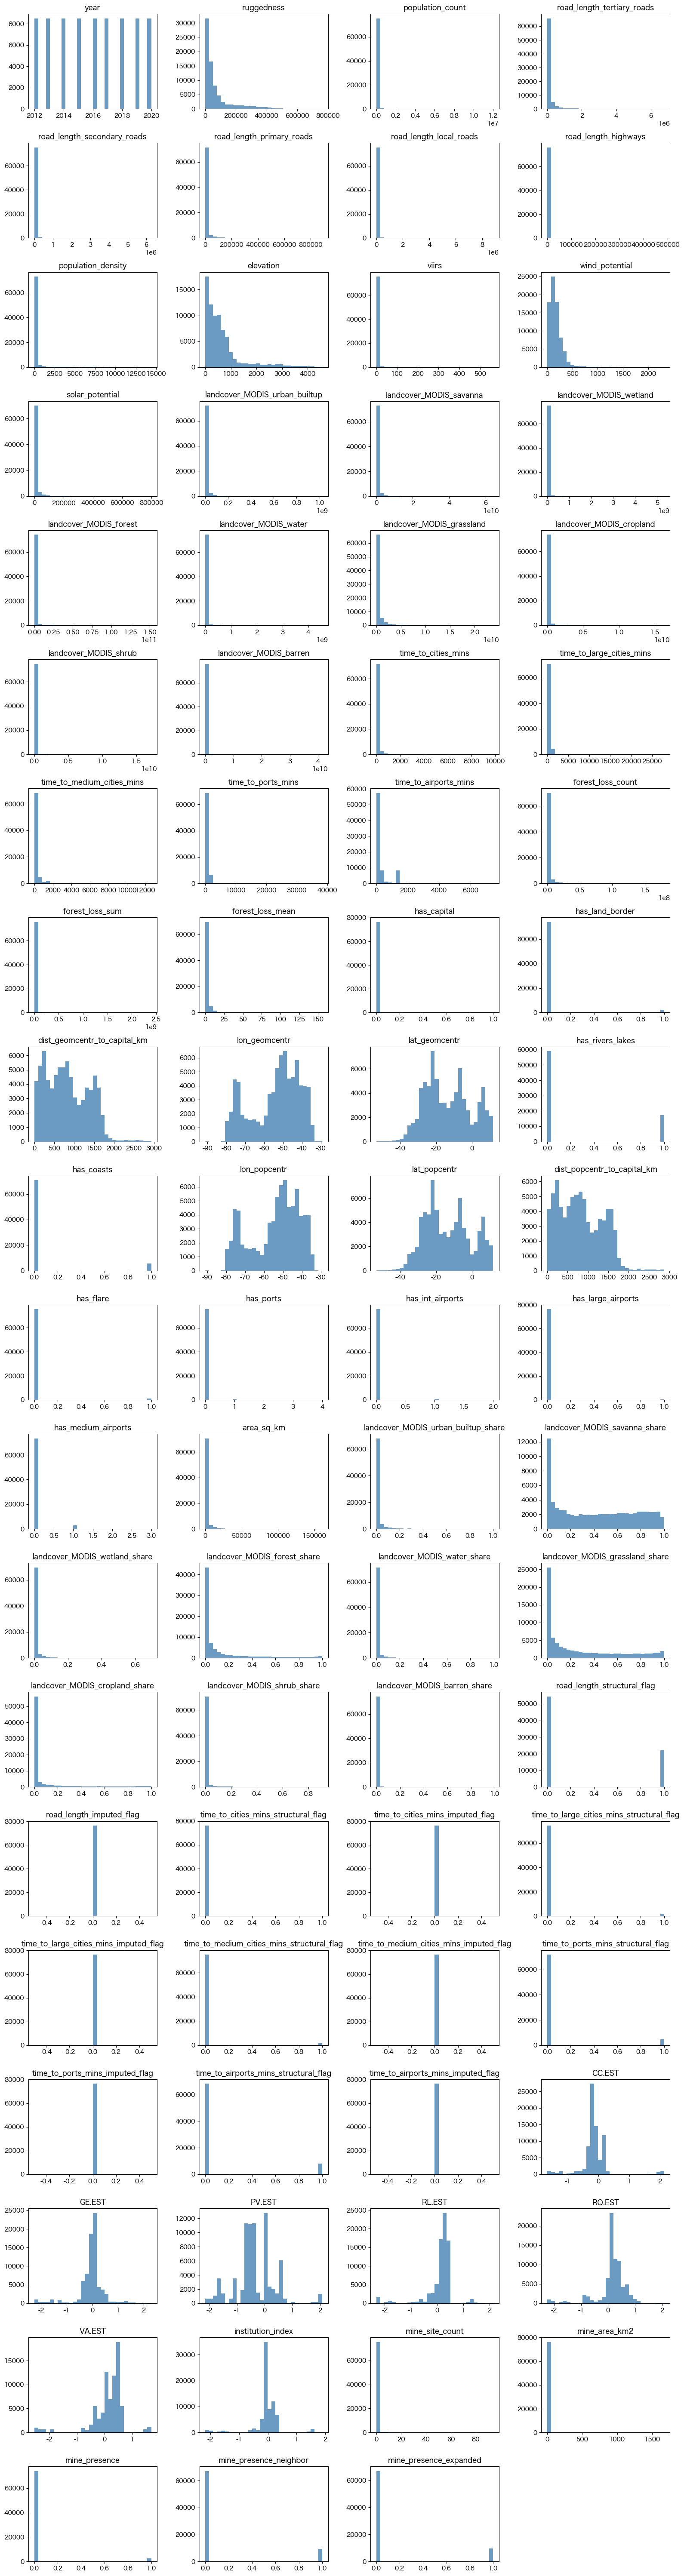

In [14]:
# --- ヒストグラム ---
import numpy as np

num_cols = analysis_df.select_dtypes(include=[np.number]).columns
if len(num_cols) == 0:
    print('No numeric columns to plot.')
else:
    n_cols = 4
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()
    for ax, col in zip(axes, num_cols):
        ax.hist(analysis_df[col].dropna(), bins=30, color='steelblue', alpha=0.8)
        ax.set_title(col)
    for ax in axes[len(num_cols):]:
        ax.set_visible(False)
    plt.tight_layout()


In [15]:
# --- Global Mining Polygons v2 (ADM2) + 隣接フラグ + 国別検証 ---

mine_path_v2 = EXTERNAL_DIR / 'Global_mining_polygons' / 'global_mining_polygons_v2.gpkg'
if not mine_path_v2.exists():
    raise FileNotFoundError(f"Mining polygons v2 not found at {mine_path_v2}")

# ADM2境界ファイル（GADM3.6, level 2）
adm2_paths = []
for iso in SOUTH_AMERICA_ISO3:
    zip_path = GLOCAL_ADM2_DIR / f"gadm36_{iso}_shp.zip"
    shp_inside = f"gadm36_{iso}_2.shp"
    if zip_path.exists():
        adm2_paths.append(f"zip://{zip_path}!{shp_inside}")
        continue
    shp_path = GLOCAL_ADM2_DIR / shp_inside
    if shp_path.exists():
        adm2_paths.append(shp_path)
if not adm2_paths:
    raise FileNotFoundError('GADM3.6 ADM2 shapefiles not found (expected gadm36_<ISO>_shp.zip).')

# ADM2境界読み込み
adm2_list = []
for path in adm2_paths:
    gdf = gpd.read_file(path)
    keep_cols = [c for c in ['GID_2','GID_1','GID_0','geometry'] if c in gdf.columns]
    gdf = gdf[keep_cols]
    adm2_list.append(gdf)
adm2_gdf = gpd.GeoDataFrame(pd.concat(adm2_list, ignore_index=True), crs=adm2_list[0].crs)

# 鉱山ポリゴン v2 読み込みと処理
mines_v2 = gpd.read_file(mine_path_v2)
mines_v2 = mines_v2.explode(index_parts=False).reset_index(drop=True)
mines_v2['geometry'] = mines_v2['geometry'].buffer(0)
if mines_v2.crs is None:
    raise ValueError('Mining polygons v2 have no CRS.')

TARGET_CRS = 'EPSG:6933'
adm2_proj = adm2_gdf.to_crs(TARGET_CRS)
mines_proj = mines_v2.to_crs(TARGET_CRS)
mines_proj['mine_area_km2_v2'] = mines_proj.geometry.area / 1e6

MIN_AREA_KM2 = 0.01
intersect = gpd.overlay(
    mines_proj[['geometry', 'mine_area_km2_v2']],
    adm2_proj[['GID_2', 'geometry']],
    how='intersection'
)
intersect['mine_area_km2_v2'] = intersect.geometry.area / 1e6
if MIN_AREA_KM2 is not None:
    intersect = intersect[intersect['mine_area_km2_v2'] >= MIN_AREA_KM2]

agg_v2 = (
    intersect.groupby('GID_2')
    .agg(mine_site_count_v2=('mine_area_km2_v2','count'),
         mine_area_km2_v2=('mine_area_km2_v2','sum'))
    .reset_index()
)
agg_v2['mine_presence_v2'] = (agg_v2['mine_site_count_v2'] > 0).astype(int)

print('Mine aggregation v2 head:')
print(agg_v2.head())
print('\nMine area v2 summary (km^2):')
print(agg_v2['mine_area_km2_v2'].describe())

# analysis_df_v2: 既存データに v2 の鉱山指標をマージ
analysis_df_v2 = analysis_df.merge(agg_v2, on='GID_2', how='left')
analysis_df_v2[['mine_site_count_v2','mine_area_km2_v2','mine_presence_v2']] = analysis_df_v2[
    ['mine_site_count_v2','mine_area_km2_v2','mine_presence_v2']
].fillna(0)

# 隣接フラグ (v2)
neighbors = gpd.sjoin(
    adm2_gdf[['GID_2','geometry']],
    adm2_gdf[['GID_2','geometry']],
    how='left',
    predicate='touches'
)
neighbors = neighbors[neighbors['GID_2_left'] != neighbors['GID_2_right']]
neighbor_map = neighbors.groupby('GID_2_left')['GID_2_right'].apply(lambda s: list(set(s.dropna())))

presence_series = analysis_df_v2.groupby('GID_2', sort=False)['mine_presence_v2'].max()

def has_neighbor_mine(gid):
    neigh = neighbor_map.get(gid, [])
    if not neigh:
        return 0
    return int(presence_series.reindex(neigh).fillna(0).gt(0).any())

analysis_df_v2['mine_presence_neighbor_v2'] = analysis_df_v2['GID_2'].map(has_neighbor_mine)
analysis_df_v2['mine_presence_expanded_v2'] = (
    (analysis_df_v2['mine_presence_v2'] == 1) |
    (analysis_df_v2['mine_presence_neighbor_v2'] == 1)
).astype(int)

# ADM2ごとの静的鉱山テーブルに国コードを付与
adm2_static_v2 = agg_v2.merge(
    adm2_gdf[['GID_2', 'GID_0']],
    on='GID_2',
    how='left',
    validate='one_to_one',  # GID_2ごとに1行のはず
)

# 国別サマリ（隣接なし・年で重複カウントもしない）
country_summary_v2 = (
    adm2_static_v2
    .groupby('GID_0')[['mine_site_count_v2', 'mine_area_km2_v2']]
    .sum()
    .rename(columns={
        'mine_site_count_v2': 'site_count_v2',
        'mine_area_km2_v2': 'area_km2_v2',
    })
)

expected_path = EXTERNAL_DIR / 'Global_mining_polygons' / 'global_mining_area_per_country_v2.csv'
expected_df = pd.read_csv(expected_path)
expected_df = expected_df[expected_df['ISO3_CODE'].isin(SOUTH_AMERICA_ISO3)].copy()
expected_df = expected_df.rename(columns={'ISO3_CODE':'GID_0','AREA':'area_csv','N_FEATURES':'site_csv'})

compare_df = country_summary_v2.reset_index().merge(expected_df[['GID_0','area_csv','site_csv']], on='GID_0', how='left')
compare_df['area_diff'] = compare_df['area_km2_v2'] - compare_df['area_csv']
compare_df['site_diff'] = compare_df['site_count_v2'] - compare_df['site_csv']

print('\n--- Country-level comparison (v2 vs csv) ---')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(compare_df)

# サニティチェック：国別に presence/expanded のシェアを確認
country_share_v2 = (
    analysis_df_v2.groupby('GID_0')[['mine_presence_v2','mine_presence_expanded_v2']]
    .mean()
    .sort_values('mine_presence_expanded_v2', ascending=False)
)
print('\nCountry share (v2, presence & expanded):')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    print(country_share_v2.to_string())


Mine aggregation v2 head:
         GID_2  mine_site_count_v2  mine_area_km2_v2  mine_presence_v2
0  ARG.10.11_1                   1          0.141274                 1
1  ARG.10.12_1                   5        385.923107                 1
2   ARG.10.2_1                   7         10.027776                 1
3   ARG.10.4_1                   3         10.619695                 1
4   ARG.10.7_1                  11          7.505530                 1

Mine area v2 summary (km^2):
count     705.000000
mean       32.836508
std       156.805766
min         0.011325
25%         0.319521
50%         1.878954
75%        10.619695
max      2109.219581
Name: mine_area_km2_v2, dtype: float64

--- Country-level comparison (v2 vs csv) ---


,GID_0,site_count_v2,area_km2_v2,area_csv,site_csv,area_diff,site_diff
0,ARG,324,2301.244884,2301.001995,334,0.242889,-10
1,BOL,141,285.844609,286.765071,138,-0.920462,3
2,BRA,2515,5891.166239,5915.785095,2427,-24.618857,88
3,CHL,676,4552.015314,4562.651757,697,-10.636443,-21
4,COL,247,769.156225,772.429696,219,-3.273471,28
5,ECU,96,70.677581,71.024639,97,-0.347058,-1
6,GUY,486,2374.427708,2388.750255,456,-14.322547,30
7,PER,780,3525.566946,3539.538441,852,-13.971495,-72
8,PRY,26,3.493529,3.516894,29,-0.023365,-3
9,SUR,344,1963.313433,1972.016180,306,-8.702748,38



Country share (v2, presence & expanded):
       mine_presence_v2  mine_presence_expanded_v2
GID_0                                             
PER            0.548718                   0.943590
CHL            0.636364                   0.818182
BOL            0.255319                   0.765957
SUR            0.274194                   0.661290
GUY            0.189655                   0.491379
ECU            0.152466                   0.448430
URY            0.057895                   0.300000
COL            0.068738                   0.297552
ARG            0.104925                   0.284797
BRA            0.055079                   0.224496
PRY            0.037559                   0.211268
VEN            0.041420                   0.130178


In [31]:
# --- GeoEPR 2021 (ADM2×year) 統合：GeoEPR-2021.geojson 固定版 ---
import geopandas as gpd
import pandas as pd
import numpy as np
import re

GEOEPR_DIR = EXTERNAL_DIR / "GeoEPR"
geoepr_path = GEOEPR_DIR / "GeoEPR-2021.geojson"
if not geoepr_path.exists():
    raise FileNotFoundError(f"GeoEPR-2021.geojson が見つかりません: {geoepr_path}")

print("Using GeoEPR file:", geoepr_path)

# analysis_df_v2 の年レンジに合わせる（例：2012-2020）
YEAR_MIN = int(pd.Series(analysis_df_v2["year"]).min())
YEAR_MAX = int(pd.Series(analysis_df_v2["year"]).max())
print(f"Target year window from analysis_df_v2: {YEAR_MIN}-{YEAR_MAX}")

# EPR Core（政治的地位：group×year）があれば結合（無ければスキップ）
core_candidates = (
    sorted(GEOEPR_DIR.glob("*core*.csv")) +
    sorted(GEOEPR_DIR.glob("*EPR*core*.csv")) +
    sorted(GEOEPR_DIR.glob("*Core*.csv"))
)
core_path = core_candidates[0] if core_candidates else None
print("Using EPR Core CSV:", core_path if core_path else "(not found; will skip political_status merge)")

# ==========
# 1) ユーティリティ
# ==========
def pick_column(cols_lower_map, candidates, name, required=True):
    for cand in candidates:
        if cand in cols_lower_map:
            return cols_lower_map[cand]
    if required:
        raise ValueError(
            f"列 {name} が見つかりません。候補: {candidates}\n既存列: {list(cols_lower_map.values())}"
        )
    return None

def coerce_year(s: pd.Series) -> pd.Series:
    if pd.api.types.is_datetime64_any_dtype(s):
        return s.dt.year.astype("Int64")

    num = pd.to_numeric(s, errors="coerce")
    if num.notna().mean() > 0.8:
        return num.round().astype("Int64")

    dt = pd.to_datetime(s, errors="coerce")
    yr = dt.dt.year.astype("Int64")

    def _extract(x):
        if pd.isna(x):
            return pd.NA
        m = re.search(r"(19|20)\d{2}", str(x))
        return int(m.group(0)) if m else pd.NA

    yr2 = s.apply(_extract).astype("Int64")
    return yr.fillna(yr2)

def normalize_status(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    return str(x).strip().lower()

def is_excluded_status(x: str) -> bool:
    s = normalize_status(x)
    if not s:
        return False
    excluded_keywords = ["powerless", "discriminat", "self-exclu", "excluded"]
    return any(k in s for k in excluded_keywords)

# ==========
# 2) GeoEPR 読み込み & 列名標準化
# ==========
geoepr_raw = gpd.read_file(geoepr_path)
print("GeoEPR columns:", list(geoepr_raw.columns))

cols_lower = {c.lower(): c for c in geoepr_raw.columns}

iso_col   = pick_column(cols_lower, ["iso3","countryiso3","country_iso3","iso","country","cntry"], "ISO3", required=False)
group_col = pick_column(cols_lower, ["group_id","groupid","gid","epr_group","group","groupname","group_name","ethgroup"], "group_id", required=True)
from_col  = pick_column(cols_lower, ["from","from_year","start","start_year","begin","beg","sdate"], "FROM", required=True)
to_col    = pick_column(cols_lower, ["to","to_year","end","end_year","until","edate"], "TO", required=True)

settle_col = None
for cand in ["settlement", "settlement_type", "settlementpattern", "settlmnt", "type", "gtype", "settle_type"]:
    if cand in cols_lower:
        settle_col = cols_lower[cand]
        break

rename_map = {group_col:"group_id", from_col:"FROM", to_col:"TO"}
if iso_col:
    rename_map[iso_col] = "ISO3"
if settle_col:
    rename_map[settle_col] = "settlement"

geoepr = geoepr_raw.rename(columns=rename_map)
keep_cols = [c for c in ["ISO3","group_id","FROM","TO","settlement","geometry"] if c in geoepr.columns]
geoepr = geoepr[keep_cols].copy()

# CRS
if geoepr.crs is None:
    geoepr = geoepr.set_crs("EPSG:4326", allow_override=True)
else:
    geoepr = geoepr.to_crs("EPSG:4326")

# FROM/TO 正規化
geoepr["FROM"] = coerce_year(geoepr["FROM"])
geoepr["TO"]   = coerce_year(geoepr["TO"])
geoepr["TO"] = geoepr["TO"].fillna(9999).astype("Int64")
geoepr = geoepr.dropna(subset=["FROM","group_id"]).copy()

# 期間フィルタ（analysis_df_v2 の年窓に合わせる）
geoepr = geoepr[(geoepr["TO"] >= YEAR_MIN) & (geoepr["FROM"] <= YEAR_MAX)].copy()

# statewide 判定
if "settlement" in geoepr.columns:
    geoepr["is_statewide"] = geoepr["settlement"].astype(str).str.contains("state", case=False, na=False)
else:
    geoepr["is_statewide"] = False

# 南米フィルタ
if "ISO3" in geoepr.columns:
    geoepr = geoepr[geoepr["ISO3"].isin(SOUTH_AMERICA_ISO3)].copy()

print("GeoEPR rows after basic filtering:", len(geoepr))

# ==========
# 3) 年次展開（FROM-TO → year）
# ==========
def make_years(fr, to):
    fr = int(fr)
    to = int(to)
    start = max(fr, YEAR_MIN)
    end   = min(to, YEAR_MAX)
    if end < start:
        return []
    return list(range(start, end + 1))

geoepr["year"] = geoepr.apply(lambda r: make_years(r["FROM"], r["TO"]), axis=1)
geoepr = geoepr.explode("year").dropna(subset=["year"]).copy()
geoepr["year"] = geoepr["year"].astype(int)

print("GeoEPR rows after explode:", len(geoepr), "| year range:", geoepr["year"].min(), "-", geoepr["year"].max())

# ==========
# 4) EPR Core を結合（あれば）
# ==========
geoepr["political_status"] = np.nan

if core_path is not None:
    core_df = pd.read_csv(core_path)
    print("EPR Core columns:", list(core_df.columns))
    core_cols = {c.lower(): c for c in core_df.columns}

    iso_core    = pick_column(core_cols, ["iso3","countryiso3","country_iso3","iso","country","cntry"], "ISO3 (core)", required=False)
    group_core  = pick_column(core_cols, ["group_id","groupid","gid","epr_group","group","groupname","group_name"], "group_id (core)", required=True)
    year_core   = pick_column(core_cols, ["year","date"], "year (core)", required=True)
    status_core = pick_column(core_cols, ["status","political_status","polstatus","access","groupstatus"], "status (core)", required=True)

    keep = [c for c in [iso_core, group_core, year_core, status_core] if c is not None]
    core_df = core_df[keep].copy()

    rename_core = {group_core:"group_id", year_core:"year", status_core:"political_status"}
    if iso_core:
        rename_core[iso_core] = "ISO3"
    core_df = core_df.rename(columns=rename_core)

    core_df["year"] = coerce_year(core_df["year"]).astype("Int64")
    core_df = core_df.dropna(subset=["group_id","year"]).copy()
    core_df["year"] = core_df["year"].astype(int)

    core_df = core_df[core_df["year"].between(YEAR_MIN, YEAR_MAX)].copy()
    if "ISO3" in core_df.columns:
        core_df = core_df[core_df["ISO3"].isin(SOUTH_AMERICA_ISO3)].copy()

    if ("ISO3" in geoepr.columns) and ("ISO3" in core_df.columns):
        merge_keys = ["ISO3","group_id","year"]
    else:
        merge_keys = ["group_id","year"]
        print("WARNING: ISO3 が片方に無いため、group_id×year のみで結合します（混同リスクあり）。")

    geoepr = geoepr.merge(core_df[merge_keys + ["political_status"]], on=merge_keys, how="left")
    print("Political status merged (nonnull):", geoepr["political_status"].notna().sum(), "of", len(geoepr))

# ==========
# 5) ADM2境界の準備
# ==========
adm2_gdf2 = adm2_gdf.copy()
if adm2_gdf2.crs is None:
    adm2_gdf2 = adm2_gdf2.set_crs("EPSG:4326", allow_override=True)
else:
    adm2_gdf2 = adm2_gdf2.to_crs("EPSG:4326")

adm2_base = adm2_gdf2[["GID_2","GID_0","geometry"]].drop_duplicates("GID_2").copy()

TARGET_CRS = "EPSG:6933"
adm2_area = adm2_base.to_crs(TARGET_CRS)
adm2_area["adm2_area_km2"] = adm2_area.geometry.area / 1e6
adm2_area_map = adm2_area.set_index("GID_2")["adm2_area_km2"]

# ==========
# 6) 交差（intersection）
# ==========
MIN_AREA_KM2 = 0.01  # 必要なら None に

geoepr_proj = geoepr[["group_id","year","political_status","is_statewide","geometry"] + (["ISO3"] if "ISO3" in geoepr.columns else [])].copy().to_crs(TARGET_CRS)
adm2_proj = adm2_base.to_crs(TARGET_CRS)

intersect = gpd.overlay(
    geoepr_proj,
    adm2_proj[["GID_2","GID_0","geometry"]],
    how="intersection"
)

intersect["inter_area_km2"] = intersect.geometry.area / 1e6
intersect["adm2_area_km2"] = intersect["GID_2"].map(adm2_area_map)

intersect = intersect[intersect["inter_area_km2"].notna() & (intersect["inter_area_km2"] > 0)].copy()
if MIN_AREA_KM2 is not None:
    intersect = intersect[intersect["inter_area_km2"] >= MIN_AREA_KM2].copy()

print("Intersection rows:", len(intersect))
print("Intersection area (km2) summary:")
print(intersect["inter_area_km2"].describe())

# ==========
# 7) ADM2×year 指標作成
# ==========
def summarize_gid2_year(df_grp: pd.DataFrame) -> pd.Series:
    gid2, year = df_grp.name
    adm2_area_val = df_grp["adm2_area_km2"].iloc[0]
    total_inter = df_grp["inter_area_km2"].sum()

    shares_norm = df_grp["inter_area_km2"] / total_inter if total_inter > 0 else np.nan
    frac = 1.0 - float(np.nansum((shares_norm ** 2))) if total_inter > 0 else np.nan

    local_df = df_grp.loc[~df_grp["is_statewide"]].copy()
    if local_df.empty:
        local_df = df_grp
    dom_row = local_df.loc[local_df["inter_area_km2"].idxmax()]
    dom_group = dom_row["group_id"]

    dom_share_cov = float(dom_row["inter_area_km2"] / adm2_area_val) if adm2_area_val and adm2_area_val > 0 else np.nan
    overlap_intensity = float(total_inter / adm2_area_val) if adm2_area_val and adm2_area_val > 0 else np.nan

    excl_share = np.nan
    if "political_status" in df_grp.columns:
        excl_mask = df_grp["political_status"].apply(is_excluded_status)
        excl_area = df_grp.loc[excl_mask, "inter_area_km2"].sum()
        excl_share = float(excl_area / adm2_area_val) if adm2_area_val and adm2_area_val > 0 else np.nan

    covered_share = float(total_inter / adm2_area_val) if adm2_area_val and adm2_area_val > 0 else np.nan

    return pd.Series({
        "GID_2": gid2,
        "year": int(year),
        "epr_group_count_poly": int(df_grp["group_id"].nunique()),
        "epr_dom_group_local": dom_group,
        "epr_dom_share_cov": dom_share_cov,
        "epr_frac_norm": frac,
        "epr_overlap_intensity": overlap_intensity,
        "epr_excluded_area_share": excl_share,
        "epr_total_covered_share": covered_share,
    })

epr_features = (
    intersect.groupby(["GID_2","year"], sort=False)
    .apply(summarize_gid2_year)
    .reset_index(drop=True)
)

print("epr_features shape:", epr_features.shape)
print("epr_features year range:", epr_features["year"].min(), "-", epr_features["year"].max())

# ==========
# 8) 保存＆analysis_df_v2へマージ（衝突回避版）
# ==========
out_feat = GEOEPR_DIR / f"epr_adm2_features_{YEAR_MIN}_{YEAR_MAX}.parquet"
epr_features.to_parquet(out_feat, index=False)
print("Saved:", out_feat)

# ★既存の古い epr_* を落としてから結合（列名衝突を防ぐ）
old_epr_cols = [c for c in analysis_df_v2.columns if c.startswith("epr_")]
print("Dropping existing epr_* columns:", len(old_epr_cols))
analysis_df_v2 = analysis_df_v2.drop(columns=old_epr_cols, errors="ignore")

before_shape = analysis_df_v2.shape
analysis_df_v2 = analysis_df_v2.merge(epr_features, on=["GID_2","year"], how="left")
print("GeoEPR統合:", "features", epr_features.shape, "| analysis_df_v2", before_shape, "->", analysis_df_v2.shape)

# ★重要：利用可能年だけ0埋め（年欠落を0と誤認しない）
max_geoepr_year = int(epr_features["year"].max())
analysis_df_v2["epr_data_available"] = (analysis_df_v2["year"] <= max_geoepr_year).astype(int)

mask_avail = analysis_df_v2["epr_data_available"] == 1
analysis_df_v2.loc[mask_avail, "epr_group_count_poly"] = (
    analysis_df_v2.loc[mask_avail, "epr_group_count_poly"].fillna(0).astype(int)
)

print("Done. max_geoepr_year =", max_geoepr_year)
print("epr_group_count_poly missing rate (available years):",
      analysis_df_v2.loc[mask_avail, "epr_group_count_poly"].isna().mean())



Using GeoEPR file: /Users/saraha/Desktop/卒業研究/データ/external/GeoEPR/GeoEPR-2021.geojson
Target year window from analysis_df_v2: 2012-2020
Using EPR Core CSV: (not found; will skip political_status merge)
GeoEPR columns: ['gwid', 'statename', 'from', 'to', 'group', 'groupid', 'gwgroupid', 'umbrella', 'sqkm', 'type', 'geometry']
GeoEPR rows after basic filtering: 811
GeoEPR rows after explode: 6617 | year range: 2012 - 2020
Intersection rows: 151641
Intersection area (km2) summary:
count    151641.000000
mean       1858.894841
std        6254.295644
min           0.010560
25%         171.716931
50%         414.419787
75%        1197.447058
max      159683.634083
Name: inter_area_km2, dtype: float64


/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_23842/863132432.py:270: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_gid2_year)


epr_features shape: (76977, 9)
epr_features year range: 2012 - 2020
Saved: /Users/saraha/Desktop/卒業研究/データ/external/GeoEPR/epr_adm2_features_2012_2020.parquet
Dropping existing epr_* columns: 15
GeoEPR統合: features (76977, 9) | analysis_df_v2 (76448, 102) -> (76448, 109)
Done. max_geoepr_year = 2020
epr_group_count_poly missing rate (available years): 0.0


In [20]:
# --- TerraClimate (2011-2020) ADM2統合 & QC ---
# 必要ライブラリチェック
try:
    import xarray as xr
    import rioxarray  # noqa: F401
    from rasterstats import zonal_stats
except ImportError as e:
    raise ImportError('TerraClimate処理に xarray, rioxarray, rasterstats が必要です。pip install xarray rioxarray rasterstats netCDF4') from e

from pathlib import Path
import numpy as np
import pandas as pd
import warnings

TC_DIR = EXTERNAL_DIR / 'TerraClimate'
RAW_DIR = TC_DIR / 'raw'
TC_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

# 年リスト抽出
years = sorted({int(y) for y in analysis_df_v2['year'].unique() if 2011 <= int(y) <= 2020})
print('対象年:', years)

# ADM2境界（zonal用はユニークGID_2のみ）
adm2_zs = adm2_gdf[['GID_2','geometry']].drop_duplicates('GID_2').to_crs('EPSG:4326')
# 南米BBox
minx, miny, maxx, maxy = adm2_zs.total_bounds
bbox_sel = dict(lon=slice(minx, maxx), lat=slice(maxy, miny))  # latは降順

# 変数セット
sum_vars = ['ppt','pet','aet','def','q']
mean_vars = ['tmax','tmin','vap','vpd','ws','srad']
state_vars = ['soil','swe','pdsi']  # 12ヶ月平均のみ（12月値は不要）
all_vars = sum_vars + mean_vars + state_vars

# ダウンロードURLテンプレ（fallback用）
HTTP_TEMPLATE = 'https://climate.northwestknowledge.net/TERRACLIMATE-DATA/TerraClimate_{var}_{year}.nc'
# OPeNDAP (全期間を部分取得) の候補。接続不可ならローカルDLにフォールバック。
THREDDS_TEMPLATE = 'https://www.northwestknowledge.net/thredds/dodsC/TERRACLIMATE_ALL/TerraClimate_{var}.nc'

def open_monthly(var):
    # 1) THREDDS/OPeNDAP（全期間ファイル）
    url_all = THREDDS_TEMPLATE.format(var=var)
    try:
        ds = xr.open_dataset(url_all, decode_times=True, mask_and_scale=True)
        da = ds[var]
        da = da.sel(time=slice(f'{years[0]}-01-01', f'{years[-1]}-12-31'), **bbox_sel)
        print(f'Loaded remote {var} via THREDDS: {da.shape}')
        return da
    except Exception as e:
        warnings.warn(f'THREDDS取得失敗: {e}; ローカルDLにフォールバック')

    # 2) ローカル（必要ならDL）
    das = []
    for yr in years:
        fp = RAW_DIR / f'TerraClimate_{var}_{yr}.nc'
        if not fp.exists():
            url = HTTP_TEMPLATE.format(var=var, year=yr)
            import subprocess, shlex
            print(f'Downloading {url} -> {fp}')
            cmd = f"curl -L -o {shlex.quote(str(fp))} {shlex.quote(url)}"
            ret = subprocess.run(cmd, shell=True)
            if ret.returncode != 0 or not fp.exists():
                raise FileNotFoundError(f'{fp} のダウンロードに失敗: {url}')
        ds_yr = xr.open_dataset(fp, decode_times=True, mask_and_scale=True)
        # 変数名の大小違いを吸収（例: pdsi -> PDSI）
        if var in ds_yr.data_vars:
            key = var
        elif var.upper() in ds_yr.data_vars:
            key = var.upper()
        elif var.lower() in ds_yr.data_vars:
            key = var.lower()
        else:
            raise KeyError(f"{fp} に '{var}' が無い: data_vars={list(ds_yr.data_vars)}")
        da_yr = ds_yr[key]
        da_yr = da_yr.sel(**bbox_sel)
        das.append(da_yr)
    da = xr.concat(das, dim='time')
    print(f'Loaded local {var}: {da.shape}')
    return da


def annualize(da, var):
    # 年次化。scale_factorはxarrayが適用済み想定。
    if var in sum_vars:
        ann = da.groupby('time.year').sum(dim='time', skipna=True)
        return {'tc_' + var: ann}
    if var in mean_vars:
        ann = da.groupby('time.year').mean(dim='time', skipna=True)
        return {'tc_' + var: ann}
    if var in state_vars:
        mean_ann = da.groupby('time.year').mean(dim='time', skipna=True)
        return {f'tc_{var}_mean': mean_ann}
    raise ValueError(f'未知の変数 {var}')


def zonal_mean(da, colname):
    # da: DataArray with dims (year, lat, lon)
    da = da.rename({'year':'year_idx'})  # avoid conflict
    da = da.rio.write_crs('EPSG:4326', inplace=False)
    records = []
    for yr in da['year_idx'].values:
        slice_da = da.sel(year_idx=yr)
        arr = slice_da.values
        aff = slice_da.rio.transform()
        zs = zonal_stats(
            adm2_zs,
            arr,
            affine=aff,
            nodata=np.nan,
            stats='mean'
        )
        for gid, stat in zip(adm2_zs['GID_2'], zs):
            records.append({'GID_2': gid, 'year': int(yr), colname: stat['mean']})
    df_out = pd.DataFrame(records)
    return df_out


# 年次ラスタ→ADM2集計
feature_dfs = []
for var in all_vars:
    da_m = open_monthly(var)
    ann_dict = annualize(da_m, var)

    for name, ann_da in ann_dict.items():

        # ====== ここが追加ポイント（VPDだけ特別扱い） ======
        # TerraClimate の vpd はごく小さい負値が出ることがあるので 0 でクリップ
        if name == 'tc_vpd':
            ann_da = ann_da.clip(min=0)
        # =====================================================

        # Sanity: 値域チェック
        desc = ann_da.to_series().describe(percentiles=[0.01, 0.5, 0.99])
        print(f'{name} describe:{desc}')

        # 非負であるべき変数のみ厳密チェック（vpdは除外）
        if name in ['tc_ppt', 'tc_pet', 'tc_aet', 'tc_q']:
            if float(ann_da.min()) < -1e-3:
                raise ValueError(f'{name} に負の値があります。スケール確認が必要')

        df_zone = zonal_mean(ann_da, name)
        feature_dfs.append(df_zone)


# tmean (オプション)
try:
    tmax_df = [d for d in feature_dfs if 'tc_tmax' in d.columns][0]
    tmin_df = [d for d in feature_dfs if 'tc_tmin' in d.columns][0]
    tm = tmax_df.merge(tmin_df, on=['GID_2','year'])
    tm['tc_tmean'] = (tm['tc_tmax'] + tm['tc_tmin']) / 2
    feature_dfs.append(tm[['GID_2','year','tc_tmean']])
except Exception as e:
    warnings.warn(f'tc_tmean を計算できませんでした: {e}')

# 結合
from functools import reduce

def merge_feats(dfs):
    return reduce(lambda l,r: l.merge(r, on=['GID_2','year'], how='outer'), dfs)

tc_features = merge_feats(feature_dfs)

# QC: 行数
expected_rows = len(adm2_zs) * len(years)
print(f'期待行数 {expected_rows}, 実際 {len(tc_features)}')
if len(tc_features) != expected_rows:
    missing = (
        pd.MultiIndex.from_product([adm2_zs['GID_2'].unique(), years], names=['GID_2','year'])
        .difference(tc_features.set_index(['GID_2','year']).index)
    )
    print('欠けている GID_2-year (上位10件):')
    print(missing[:10])

# 欠損率
missing_rate = tc_features.drop(columns=['GID_2','year']).isna().mean().sort_values(ascending=False)
print('欠損率 (tc_*):', missing_rate)

# 国コード付与して国別平均
gid_country = analysis_df_v2[['GID_2','GID_0']].drop_duplicates('GID_2')
tc_features = tc_features.merge(gid_country, on='GID_2', how='left')
country_mean = tc_features.groupby('GID_0').mean(numeric_only=True)
print('国別平均 (head):')
print(country_mean.head())

# 値域チェック
print('値域 describe:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tc_features.drop(columns=['GID_2','year','GID_0']).describe())

# analysis_df_v2 に統合（tc_欠損はNaNのまま）
tc_cols = [c for c in tc_features.columns if c.startswith('tc_')]
analysis_df_v2 = analysis_df_v2.merge(tc_features[['GID_2','year'] + tc_cols], on=['GID_2','year'], how='left')

# 保存
tc_out = TC_DIR / 'tc_adm2_features_2011_2020.parquet'
tc_features.to_parquet(tc_out, index=False)
print('tc_features saved to', tc_out)

prepared_out = OUTPUT_DIR / 'south_america_adm2_prepared_v2.parquet'
analysis_df_v2.to_parquet(prepared_out, index=False)
print('analysis_df_v2 (with tc_) saved to', prepared_out)


対象年: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <!doctype^ html><title>404</title><h1>Not Found</h1>
/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_23842/1088444472.py:51: UserWarning: THREDDS取得失敗: [Errno -90] NetCDF: file not found: 'https://www.northwestknowledge.net/thredds/dodsC/TERRACLIMATE_ALL/TerraClimate_ppt.nc'; ローカルDLにフォールバック
  warnings.warn(f'THREDDS取得失敗: {e}; ローカルDLにフォールバック')


Loaded local ppt: (108, 1726, 1935)
tc_ppt describe:count    3.005829e+07
mean     4.054812e+02
std      8.166476e+02
min      0.000000e+00
1%       0.000000e+00
50%      0.000000e+00
99%      3.214700e+03
max      1.781840e+04
Name: ppt, dtype: float64


syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <!doctype^ html><title>404</title><h1>Not Found</h1>
/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_23842/1088444472.py:51: UserWarning: THREDDS取得失敗: [Errno -90] NetCDF: file not found: 'https://www.northwestknowledge.net/thredds/dodsC/TERRACLIMATE_ALL/TerraClimate_pet.nc'; ローカルDLにフォールバック
  warnings.warn(f'THREDDS取得失敗: {e}; ローカルDLにフォールバック')


Loaded local pet: (108, 1726, 1935)
tc_pet describe:count    3.005829e+07
mean     3.567810e+02
std      5.911978e+02
min      0.000000e+00
1%       0.000000e+00
50%      0.000000e+00
99%      1.673900e+03
max      2.380100e+03
Name: pet, dtype: float64


...

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   387  100   387    0     0    587      0 --:--:-- --:--:-- --:--:--   588
100 58.6M  100 58.6M    0     0  1756k      0  0:00:34  0:00:34 --:--:-- 2027k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   387  100   387    0     0    499      0 --:--:-- --:--:-- --:--:--   499
100 58.4M  100 58.4M    0     0  2857k      0  0:00:20  0:00:20 --:--:-- 2797k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   387  100   387    0     0    601      0 --:--:-- --:--:-- --:--:--   600
100 66.9M  100 66.9M    0     0  2546k      0  0:00:26  0:00:26 --:--:-- 2222k


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   387  100   387    0     0    622      0 --:--:-- --:--:-- --:--:--   623
100  143M  100  143M    0     0  2100k      0  0:01:09  0:01:09 --:--:-- 2155k


Loaded local pdsi: (108, 1726, 1935)
tc_pdsi_mean describe:count    8.304921e+06
mean    -7.823024e-01
std      2.853981e+00
min     -2.243750e+01
1%      -7.208333e+00
50%     -7.750000e-01
99%      6.160833e+00
max      2.841667e+01
Name: PDSI, dtype: float64
期待行数 77193, 実際 77193
欠損率 (tc_*): tc_ppt          0.00478
tc_pet          0.00478
tc_aet          0.00478
tc_def          0.00478
tc_q            0.00478
tc_tmax         0.00478
tc_tmin         0.00478
tc_vap          0.00478
tc_vpd          0.00478
tc_ws           0.00478
tc_srad         0.00478
tc_soil_mean    0.00478
tc_swe_mean     0.00478
tc_pdsi_mean    0.00478
tc_tmean        0.00478
dtype: float64
国別平均 (head):
         year       tc_ppt       tc_pet       tc_aet      tc_def        tc_q  \
GID_0                                                                          
ARG    2016.0   728.081790  1376.820720   622.088264  754.732533  106.562122   
BOL    2016.0   878.536168  1292.162249   656.935840  635.226441  225.018581 

In [24]:
# ===== 0) 事前行数 =====
before_n = len(tc_features)
print(f"Before cleaning: {before_n:,} rows")

# ===== 1) SWE の上側ウィンズライズ =====
# 上位 0.1% を上限にする（研究用途として無難）
swe_col = "tc_swe_mean"
swe_cap = tc_features[swe_col].quantile(0.999)

print(f"SWE cap (99.9% quantile): {swe_cap:.3f}")

tc_features[swe_col] = tc_features[swe_col].where(
    tc_features[swe_col] <= swe_cap,
    swe_cap
)

# 確認
print("SWE after winsorization:")
print(tc_features[swe_col].describe())

# ===== 2) tc_* がすべて欠損の行を drop =====
tc_cols = [c for c in tc_features.columns if c.startswith("tc_")]

all_missing_mask = tc_features[tc_cols].isna().all(axis=1)
n_all_missing = all_missing_mask.sum()

print(f"Rows with all tc_* missing: {n_all_missing:,}")

tc_features_clean = tc_features.loc[~all_missing_mask].copy()

# ===== 3) 行数レポート =====
after_n = len(tc_features_clean)
dropped_n = before_n - after_n

print(f"After cleaning: {after_n:,} rows")
print(f"Dropped rows: {dropped_n:,}")

# ===== 4) 年×ADM2 の欠損が無いか最終チェック =====
check_missing = tc_features_clean[tc_cols].isna().mean().sort_values(ascending=False)
print("Missing rate after cleaning (tc_*):")
print(check_missing)

Before cleaning: 77,193 rows
SWE cap (99.9% quantile): 70.090
SWE after winsorization:
count    77193.000000
mean         0.518794
std          5.584512
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         70.089637
Name: tc_swe_mean, dtype: float64
Rows with all tc_* missing: 0
After cleaning: 77,193 rows
Dropped rows: 0
Missing rate after cleaning (tc_*):
tc_ppt          0.00478
tc_pet          0.00478
tc_aet          0.00478
tc_def          0.00478
tc_q            0.00478
tc_tmax         0.00478
tc_tmin         0.00478
tc_vap          0.00478
tc_vpd          0.00478
tc_ws           0.00478
tc_srad         0.00478
tc_soil_mean    0.00478
tc_pdsi_mean    0.00478
tc_tmean        0.00478
tc_swe_mean     0.00000
dtype: float64


In [38]:
summarize_missing(analysis_df_v2)

,missing_ratio
GID_2,0.0
year,0.0
ruggedness,0.0
population_count,0.0
road_length_tertiary_roads,0.0
road_length_secondary_roads,0.0
road_length_primary_roads,0.0
road_length_local_roads,0.0
road_length_highways,0.0
population_density,0.0


In [37]:
# ===== 0) 事前行数 =====
before_n = len(analysis_df_v2)
print(f"Before dropna: {before_n:,} rows")

# ===== 1) 欠損行をドロップ =====
analysis_df_v2 = analysis_df_v2.dropna().copy()

# ===== 2) 事後行数 =====
after_n = len(analysis_df_v2)
dropped_n = before_n - after_n

print(f"After dropna:  {after_n:,} rows")
print(f"Dropped rows: {dropped_n:,}")


Before dropna: 76,448 rows
After dropna:  75,969 rows
Dropped rows: 479


In [40]:
drop_cols = [
    "epr_dom_group_local",        # IDなのでまず外す（記述用に残すなら別データで）
    "mine_site_count",	"mine_area_km2",	"mine_presence",	"mine_presence_neighbor",	"mine_presence_expanded",
    "epr_excluded_area_share",    # 全部0なら定数
    "epr_data_available",         # 全部1なら定数
    "epr_total_covered_share",    # overlap_intensityと冗長なら片方落とす（どっち残すかは好み）
]

# 実在する列だけ落とす
drop_cols = [c for c in drop_cols if c in analysis_df_v2.columns]
analysis_df_v2 = analysis_df_v2.drop(columns=drop_cols)

print("Dropped:", drop_cols)
print("Shape:", analysis_df_v2.shape)


Dropped: ['epr_dom_group_local', 'mine_site_count', 'mine_area_km2', 'mine_presence', 'mine_presence_neighbor', 'mine_presence_expanded', 'epr_excluded_area_share', 'epr_data_available', 'epr_total_covered_share']
Shape: (75969, 101)


In [41]:
analysis_df_v2.head(30)

,GID_2,year,ruggedness,population_count,road_length_tertiary_roads,road_length_secondary_roads,road_length_primary_roads,road_length_local_roads,road_length_highways,population_density,elevation,viirs,wind_potential,solar_potential,landcover_MODIS_urban_builtup,landcover_MODIS_savanna,landcover_MODIS_wetland,landcover_MODIS_forest,landcover_MODIS_water,landcover_MODIS_grassland,landcover_MODIS_cropland,landcover_MODIS_shrub,landcover_MODIS_barren,time_to_cities_mins,time_to_large_cities_mins,time_to_medium_cities_mins,time_to_ports_mins,time_to_airports_mins,forest_loss_count,forest_loss_sum,forest_loss_mean,has_capital,has_land_border,dist_geomcentr_to_capital_km,lon_geomcentr,lat_geomcentr,has_rivers_lakes,has_coasts,lon_popcentr,lat_popcentr,dist_popcentr_to_capital_km,has_flare,has_ports,has_int_airports,has_large_airports,has_medium_airports,GID_1,GID_0,area_sq_km,landcover_MODIS_urban_builtup_share,landcover_MODIS_savanna_share,landcover_MODIS_wetland_share,landcover_MODIS_forest_share,landcover_MODIS_water_share,landcover_MODIS_grassland_share,landcover_MODIS_cropland_share,landcover_MODIS_shrub_share,landcover_MODIS_barren_share,road_length_structural_flag,road_length_imputed_flag,time_to_cities_mins_structural_flag,time_to_cities_mins_imputed_flag,time_to_large_cities_mins_structural_flag,time_to_large_cities_mins_imputed_flag,time_to_medium_cities_mins_structural_flag,time_to_medium_cities_mins_imputed_flag,time_to_ports_mins_structural_flag,time_to_ports_mins_imputed_flag,time_to_airports_mins_structural_flag,time_to_airports_mins_imputed_flag,CC.EST,GE.EST,PV.EST,RL.EST,RQ.EST,VA.EST,institution_index,mine_site_count_v2,mine_area_km2_v2,mine_presence_v2,mine_presence_neighbor_v2,mine_presence_expanded_v2,tc_ppt,tc_pet,tc_aet,tc_def,tc_q,tc_tmax,tc_tmin,tc_vap,tc_vpd,tc_ws,tc_srad,tc_soil_mean,tc_swe_mean,tc_pdsi_mean,tc_tmean,epr_group_count_poly,epr_dom_share_cov,epr_frac_norm,epr_overlap_intensity
0,ARG.1.100_1,2012,6732.596191,13596.339844,303311.625,0.000000,12369.510742,0.0,0.0,8.743810,24.756420,0.136705,311.789032,9836.143555,8132194.0,8.646025e+06,4.949884e+06,0.000000,34749188.0,1.426693e+09,7.660271e+07,0.0,0.00,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,13646.330078,0.006397,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.005543,0.003173,0.000000,0.022278,0.914680,0.049111,0.0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,-0.245731,-0.084966,0.755316,-0.271374,-0.831479,0.247331,-0.071817,0.0,0.0,0.0,0,0,1355.232955,1211.965909,1014.025000,197.940909,296.719318,23.209830,10.656307,1.432204,0.755578,2.933551,188.440909,37.473011,0.0,-0.147121,16.933068,2.0,0.221142,0.296599,1.221142
1,ARG.1.100_1,2013,6732.596191,13779.962891,303311.625,0.000000,12369.510742,0.0,0.0,8.861900,24.756420,0.162356,311.789032,9836.143555,8132194.0,1.230320e+07,7.432259e+06,0.000000,34749188.0,1.403603e+09,9.355333e+07,0.0,0.00,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,24909.259766,0.011676,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.007888,0.004765,0.000000,0.022278,0.899876,0.059979,0.0,0.000000,0,0,0,0,0,0,0,0,0,0,1,0,-0.223999,-0.171848,0.624557,-0.314306,-0.879585,0.212428,-0.125459,0.0,0.0,0.0,0,0,888.980682,1262.823864,827.497727,435.326136,99.461364,23.319044,9.855218,1.370550,0.786989,2.988078,200.192519,30.195739,0.0,1.506600,16.587131,2.0,0.221142,0.296599,1.221142
2,ARG.1.100_1,2014,6732.596191,13966.066406,303311.625,0.000000,12369.510742,0.0,0.0,8.981586,24.756420,0.168650,311.789032,9836.143555,8132194.0,1.596115e+07,1.104536e+07,0.000000,34749188.0,1.385986e+09,1.038992e+08,0.0,0.00,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,35725.730469,0.016747,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.010233,0.00

In [42]:
# 保存先パスを指定
out_csv = "analysis_df_v2.csv"

# CSVとして保存
analysis_df_v2.to_csv(out_csv, index=False)

print("Saved:", out_csv)


Saved: analysis_df_v2.csv


In [43]:
# --- 前処理済みデータの保存 ---
prepared_path = OUTPUT_DIR / 'south_america_adm2_prepared.parquet'
analysis_df.to_parquet(prepared_path, index=False)
print('Saved prepared data to', prepared_path)

prepared_path_v2 = OUTPUT_DIR / 'south_america_adm2_prepared_v2.parquet'
analysis_df_v2.to_parquet(prepared_path_v2, index=False)
print('Saved prepared data (v2 mining flags) to', prepared_path_v2)


Saved prepared data to /Users/saraha/Desktop/卒業研究/データ/processed/south_america_adm2_prepared.parquet
Saved prepared data (v2 mining flags) to /Users/saraha/Desktop/卒業研究/データ/processed/south_america_adm2_prepared_v2.parquet
